# CREATE HULL OF FIRST CONNECTED COMPOSANT OF NETKDE RESULT BY TOPONYM

    # LOAD PACKAGES AND LIB

In [1]:
import pandas as pd 
import geopandas as gpd
import pickle 
##CREATE SHAPEFILL DATA FROM EXCEL FILE
import fiona
from collections import OrderedDict
from pyproj import Transformer
from geopandas import GeoDataFrame
from shapely.geometry import Point
import folium
import geopy
import networkx
import osmnx as ox
#import Rtree
import shapely
import matplotlib.pyplot as plt
import shapefile
#from itoolbox import connect_poi
import momepy
#http://docs.momepy.org/en/stable/user_guide/graph/convert.html
import alphashape
from scipy.spatial import ConvexHull
import ogr 

## INTERSECTION OF DATA WITH SHAPELY

import shapely.speedups
shapely.speedups.enable()  # active shapely.speedups qui accélère l'exécution des requêtes.


c:\users\ablanchi\appdata\local\programs\python\python36\lib\site-packages\geopandas\_compat.py:110: UserWarning: The Shapely GEOS version (3.8.0-CAPI-1.13.1 ) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
import networkx as nx
import shapely
from shapely.geometry import MultiLineString, MultiPolygon
from shapely.ops import linemerge
import networkx as nx 

import shapely.speedups
shapely.speedups.enable()

import json

    # IMPORT LIXELS FROM NETKDE RESULT 

In [3]:
VILLE = "NICE"

In [4]:
#pd.read_csv("C:/Users/ablanchi/Desktop/lixels_cannes_test_more_50.csv", delimiter=';')

df = pd.read_excel("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/LIXELS_NETKDE_POSITF.xlsx", engine='openpyxl')

In [5]:
## IMPORT NETWORK OR LIXELS
streets = gpd.read_file("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/LIXELS_VILLE.shp")
streets = streets.to_crs("EPSG:2154")

In [6]:
streets.columns

Index(['lineID', 'uid', 'troncon_de', 'troncon__1', 'troncon__2', 'troncon__3',
       'NOM_count', 'NOM_unique', 'NOM_empty', 'NOM_filled', 'NOM_min',
       'NOM_max', 'NOM_min_le', 'NOM_max_le', 'NOM_mean_l', 'geometry'],
      dtype='object')

In [7]:
lixels = streets[['lineID', 'uid', 'geometry']]


lixels1 = lixels.merge(df, on ="lineID")


In [8]:
gdf = GeoDataFrame(lixels1, crs="EPSG:2154", geometry=lixels1.geometry_x)


In [9]:
path = "C:/GIT/2022/TOPONOMASCAPE/VILLE/ALPES-MARITIMES/1_ADS_RELOCALIZED.pickle"
file = open(path, "rb")
ADS_AM = pickle.load(file)
file.close()

In [10]:
gdf.columns

Index(['lineID', 'uid_x', 'geometry_x', 'uid_y', 'troncon_de', 'troncon__1',
       'troncon__2', 'troncon__3', 'NOM_count', 'NOM_unique',
       ...
       'verdi', 'vernier', 'viager', 'victor hugo', 'vieille ville', 'vieux',
       'vieux nice', 'virgile barel', 'wilson', 'geometry'],
      dtype='object', length=234)

# APPLICATION 

    # COMPOSANTE CONNEXE
> 1. Sélectionner la première composante connexe:
- Pour chaque toponyme (chaque colonne du df lixels): 
- Prendre les lixels > 0 
- Appliquer les composantes connexes 
- Extraire la première composante connexe
- Pour chaque lixel qui n'appartient pas à la première CC : 0) sinon lixel$toponym : result. 
-----------> Output : Nouveu Lixels .csv POSITIF

    # PHENOMENE POSITIF (GDF _LIXELS _ POSITIF)

In [11]:
notcol = ('lineID', 'uid_x', 'troncon_de_x', 'geometry_x', 'uid_y',
       'troncon_de_y', 'troncon__1', 'troncon__2', 'troncon__3', 'NOM_count',
       'NOM_unique', 'NOM_empty', 'NOM_filled', 'NOM_min', 'NOM_max',
       'NOM_min_le', 'NOM_max_le', 'NOM_mean_l', 'geometry_y', "uid", 'lineID', 'uid_x', 'trncn_d', 'geometry_x', 'uid_y', 'troncon_de',
       'troncon__1', 'troncon__2', 'troncon__3', 'geometry_y', 'geometry')

acropolis
longueur 1039
in cc 820


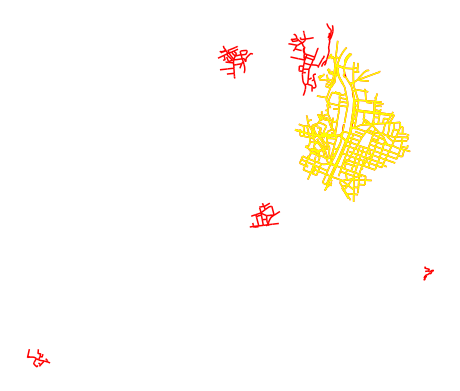

alban
longueur 1992
in cc 1242


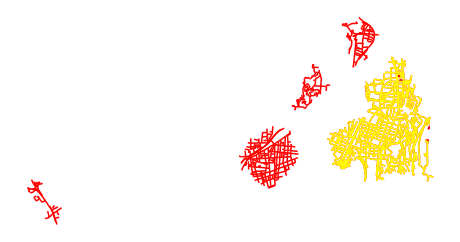

alphonse karr
longueur 240
in cc 228


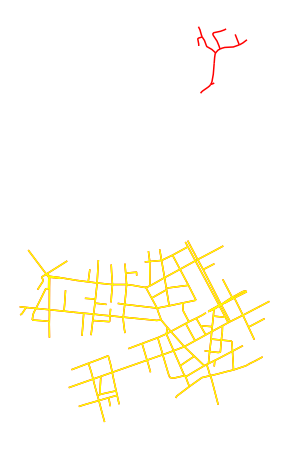

alsace lorraine
longueur 632
in cc 617


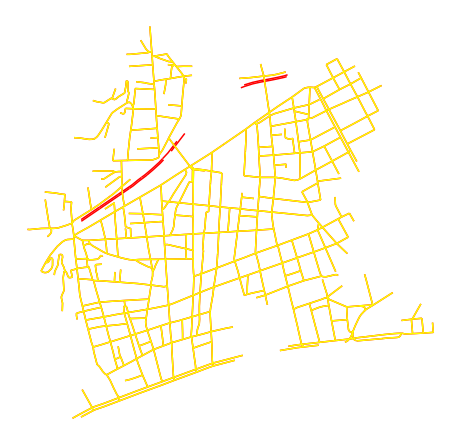

andrioli
longueur 210
in cc 203


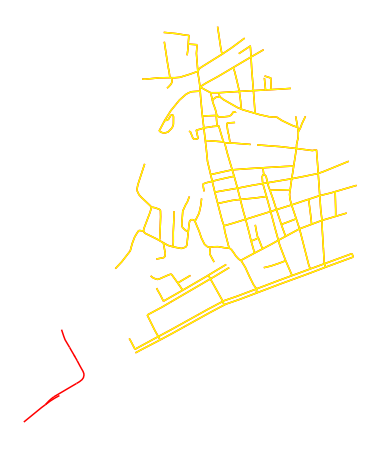

anglais
longueur 2560
in cc 1850


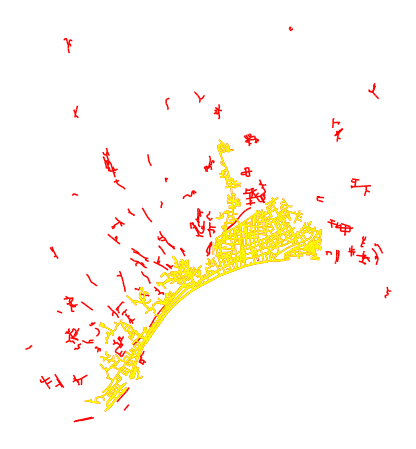

antiquaires
longueur 250
in cc 186


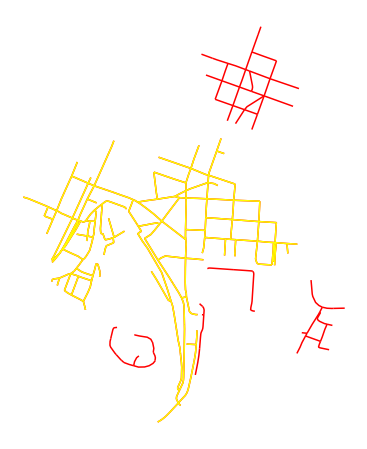

antoine
longueur 811
in cc 571


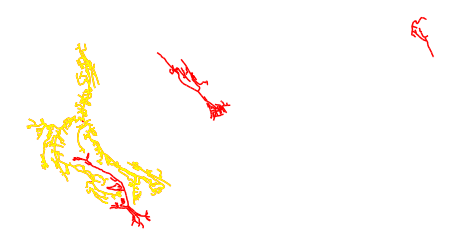

antoine ginestiere
longueur 472
in cc 299


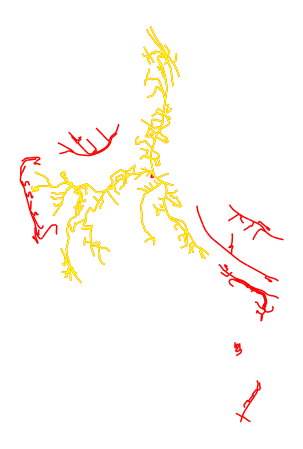

archet
longueur 921
in cc 724


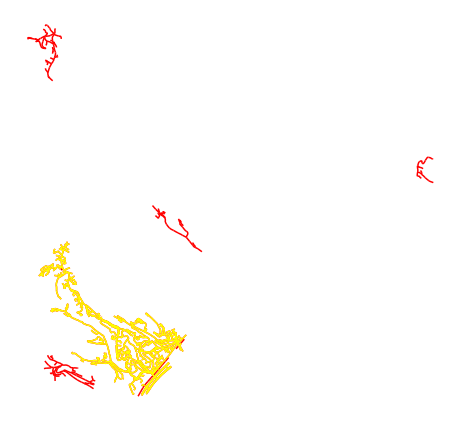

arenas
longueur 663
in cc 424


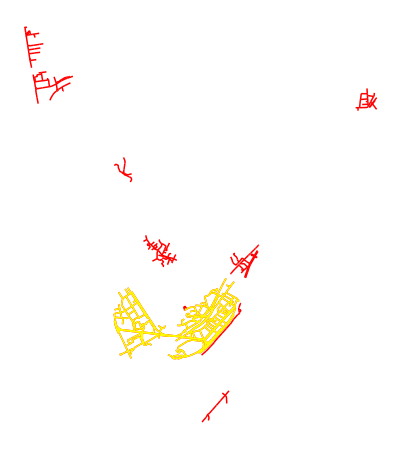

arenes
longueur 474
in cc 421


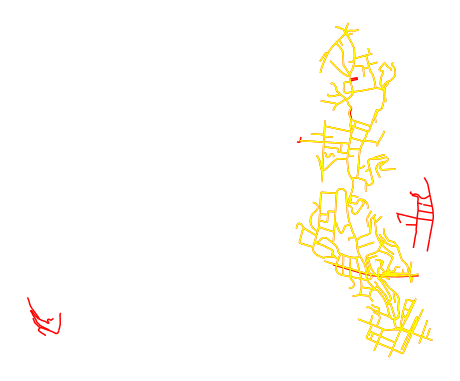

ariane
longueur 144
in cc 124


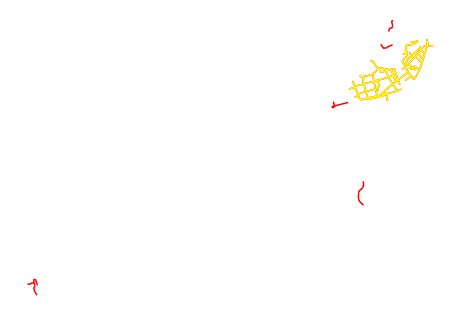

arson
longueur 812
in cc 352


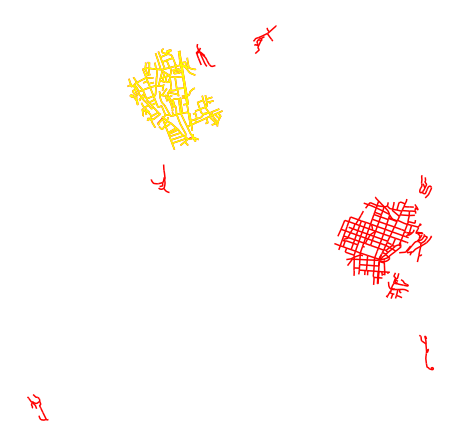

auguste raynaud
longueur 238
in cc 223


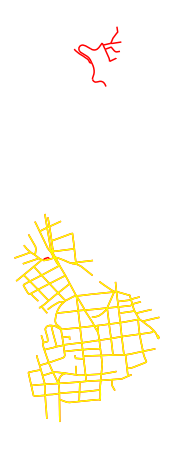

augustin
longueur 1232
in cc 750


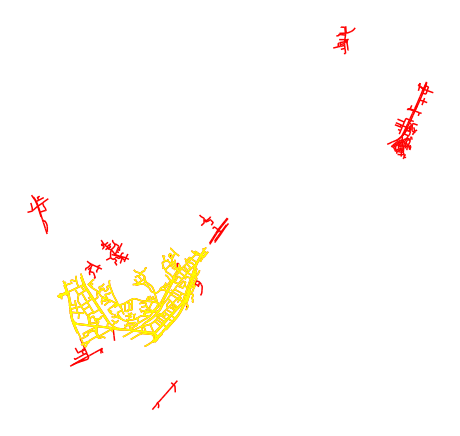

baie anges
longueur 7642
in cc 4331


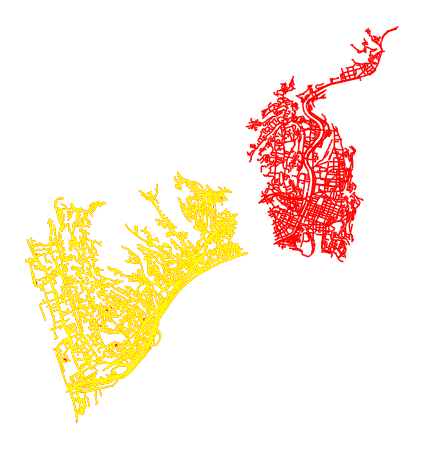

barberis
longueur 97
in cc 44


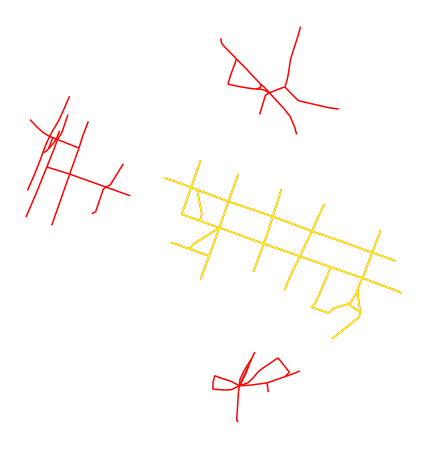

barla
longueur 508
in cc 323


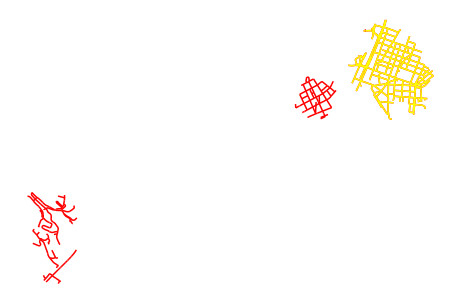

barthelemy
longueur 463
in cc 342


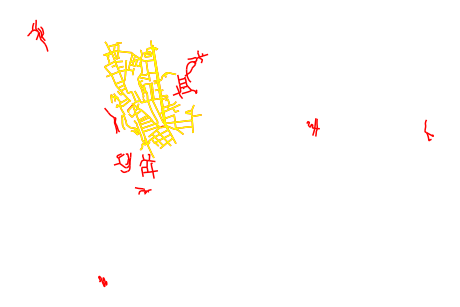

baumettes
longueur 1103
in cc 822


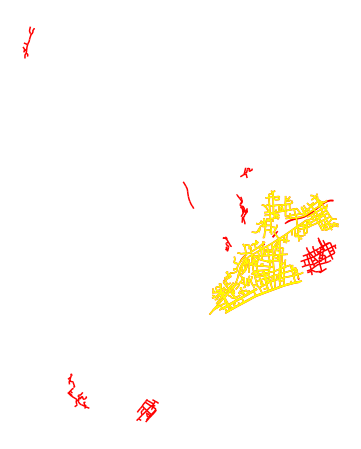

bellet
longueur 1217
in cc 556


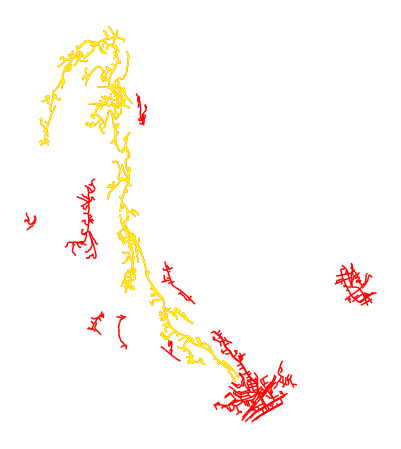

bellevue
longueur 794
in cc 526


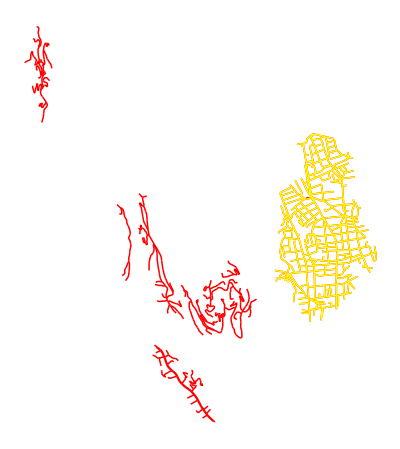

berlioz
longueur 104
in cc 92


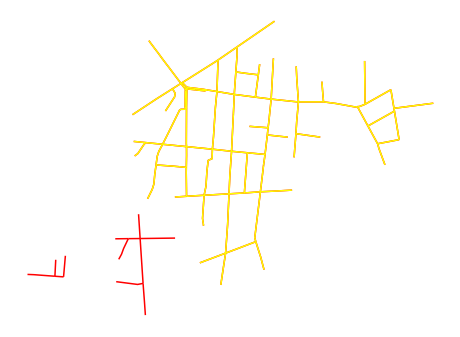

besset
longueur 310
in cc 276


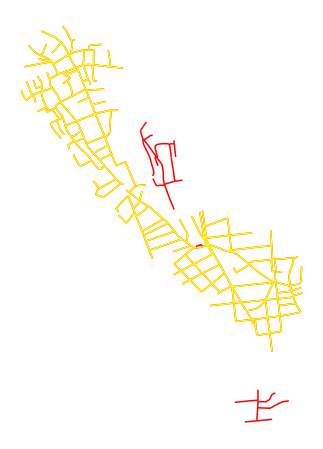

blue pearl
longueur 545
in cc 331


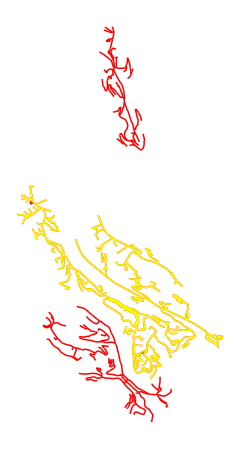

bonaparte
longueur 377
in cc 364


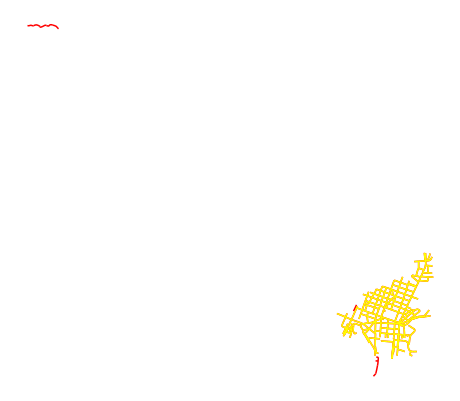

bornala
longueur 152
in cc 117


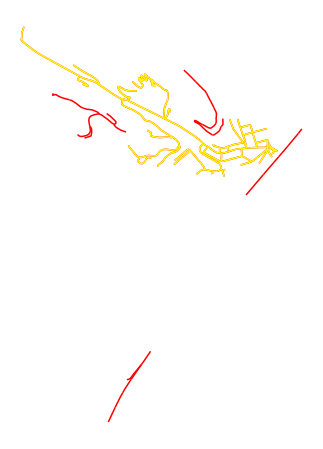

boron
longueur 1178
in cc 711


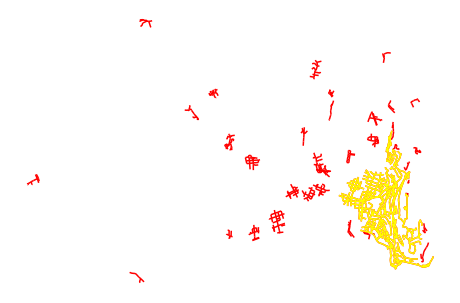

borriglione
longueur 508
in cc 379


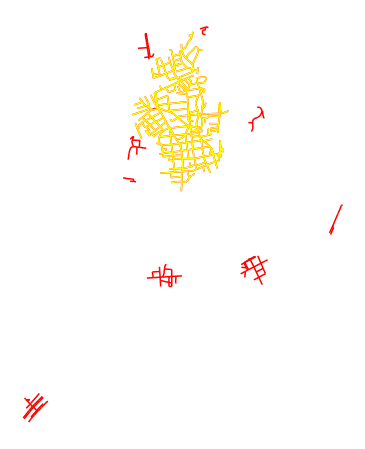

bottero
longueur 346
in cc 313


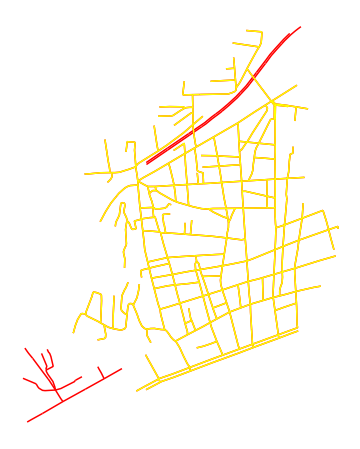

brancolar
longueur 272
in cc 221


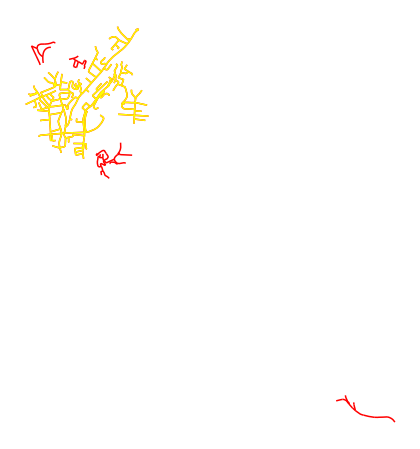

buffa
longueur 297
in cc 226


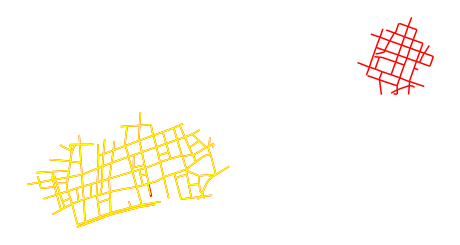

californie
longueur 507
in cc 333


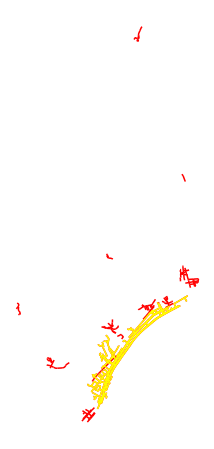

canta
longueur 236
in cc 108


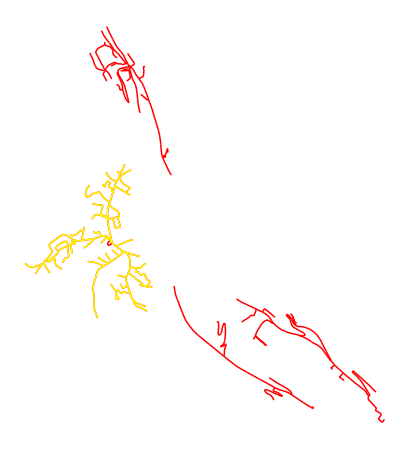

cap antibes
longueur 4363
in cc 2263


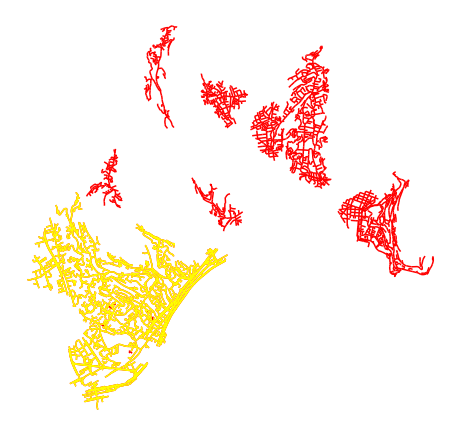

cap croix
longueur 614
in cc 261


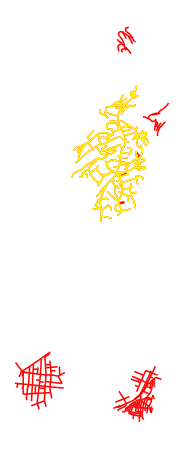

cap ferrat
longueur 1940
in cc 1738


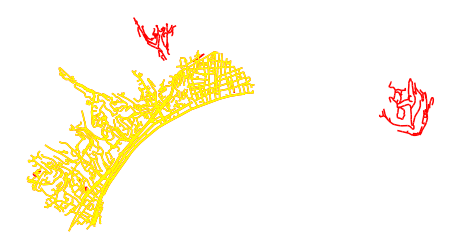

cap nice
longueur 265
in cc 136


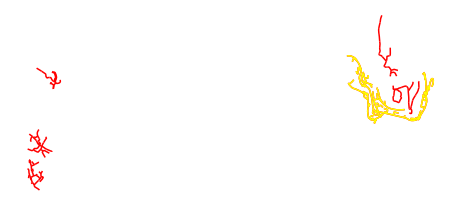

carabacel
longueur 301
in cc 247


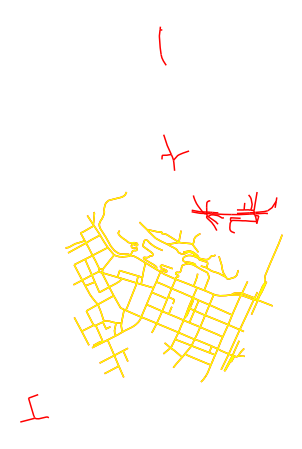

carlone
longueur 927
in cc 439


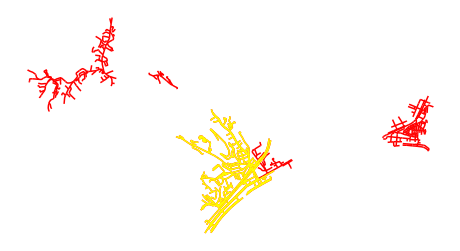

carras
longueur 502
in cc 410


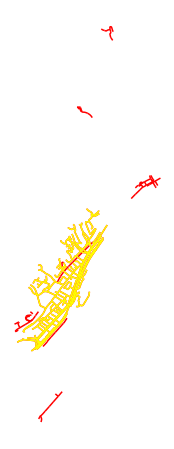

carre or
longueur 553
in cc 418


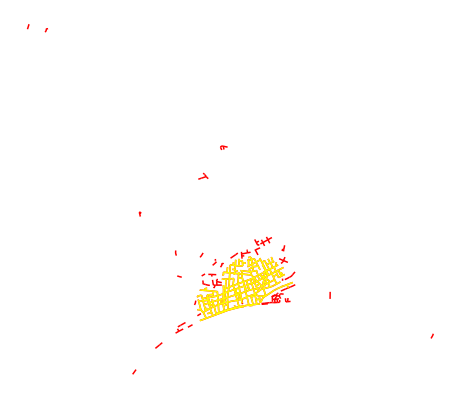

cassini
longueur 84
in cc 55


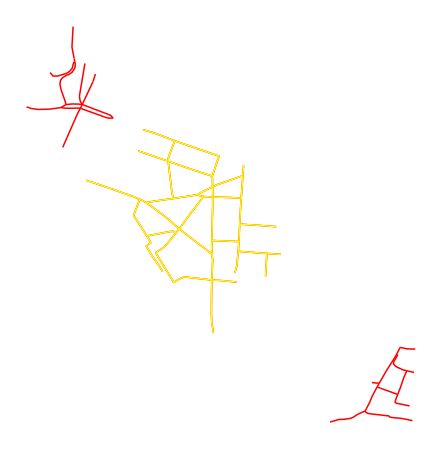

caucade
longueur 587
in cc 468


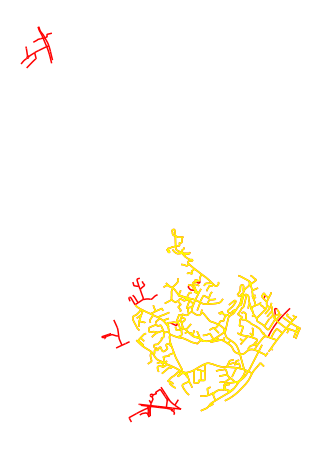

cessole
longueur 521
in cc 361


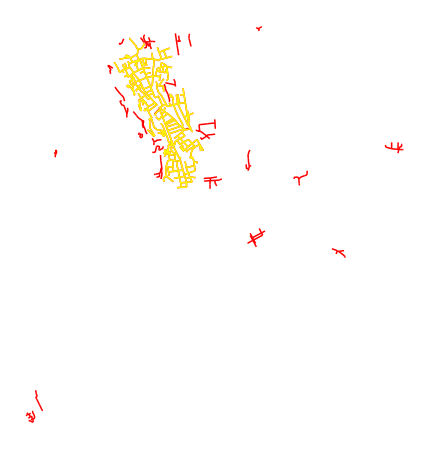

chambrun
longueur 442
in cc 318


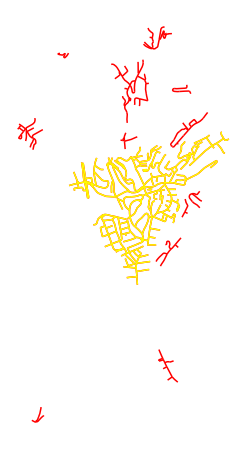

chateau
longueur 3046
in cc 1701


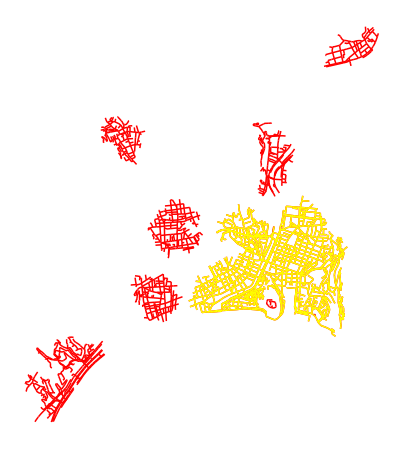

chateauneuf
longueur 67
in cc 41


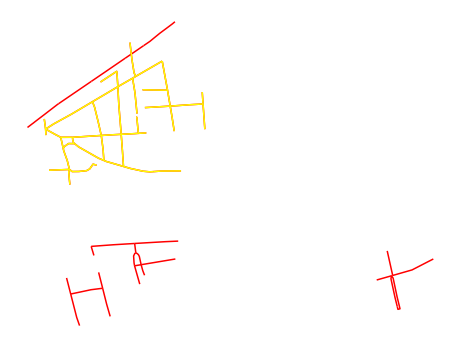

cimiez
longueur 1464
in cc 884


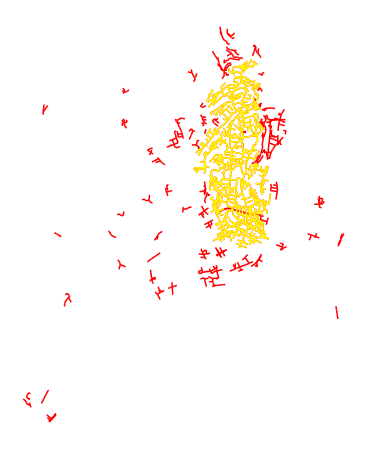

clemenceau
longueur 231
in cc 166


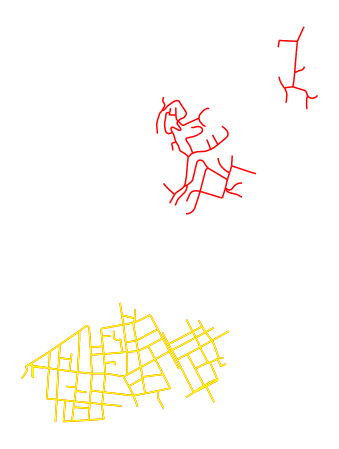

cluvier
longueur 32
in cc 29


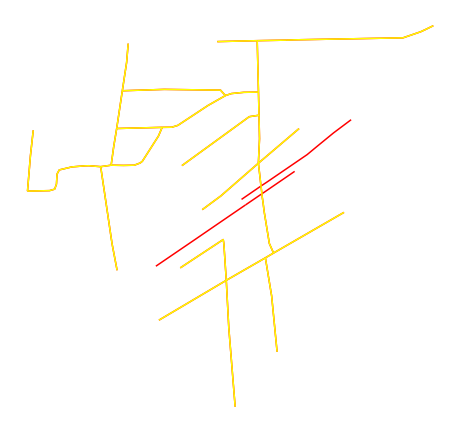

collines
longueur 3055
in cc 2344


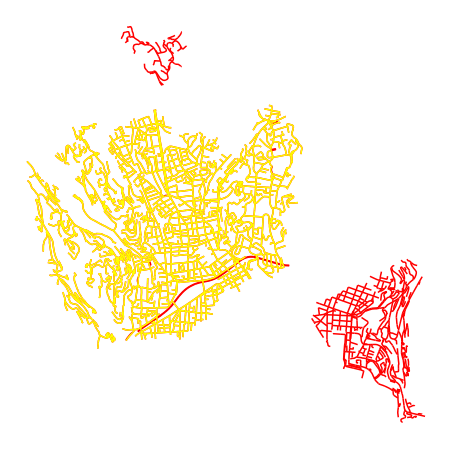

congres
longueur 42
in cc 42


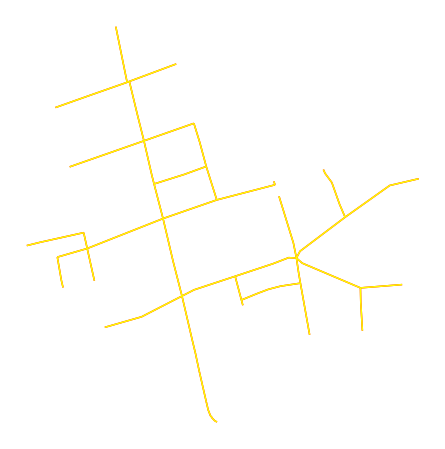

costiere
longueur 322
in cc 219


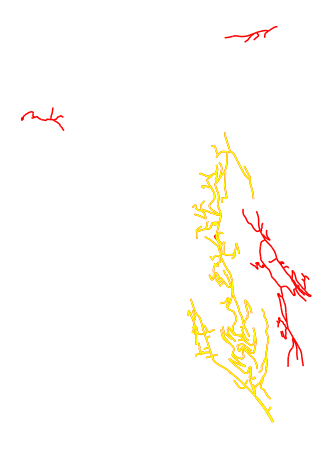

coulee verte
longueur 799
in cc 799


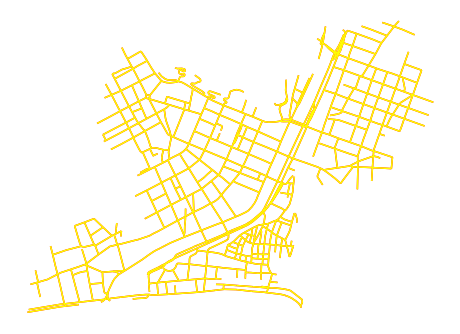

cours saleya
longueur 404
in cc 377


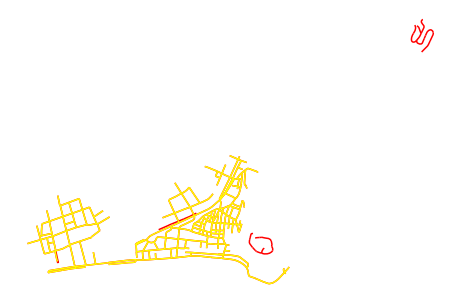

cremat
longueur 2438
in cc 1467


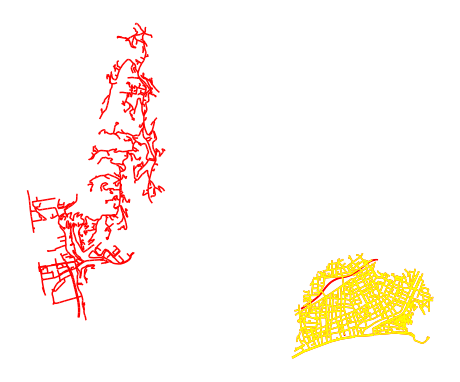

cyrille
longueur 251
in cc 238


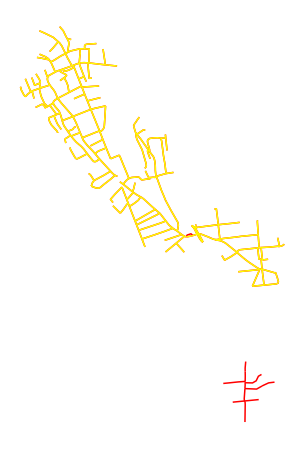

cyrille besset
longueur 213
in cc 181


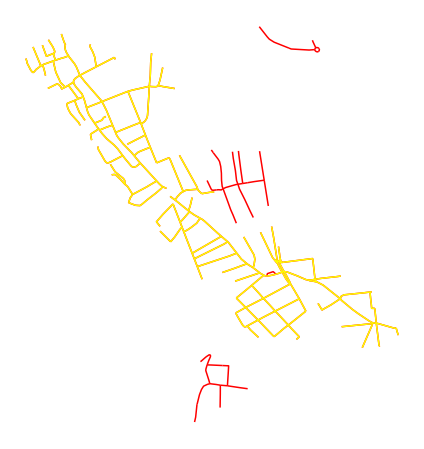

de
longueur 6446
in cc 5581


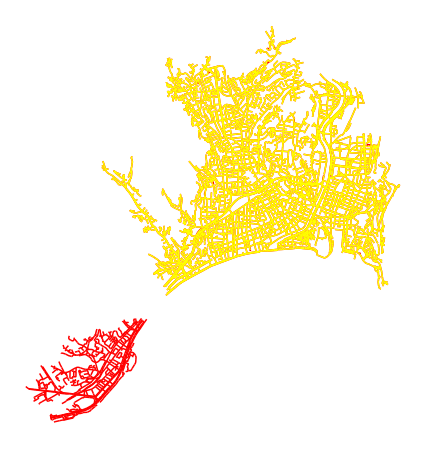

delfino
longueur 184
in cc 153


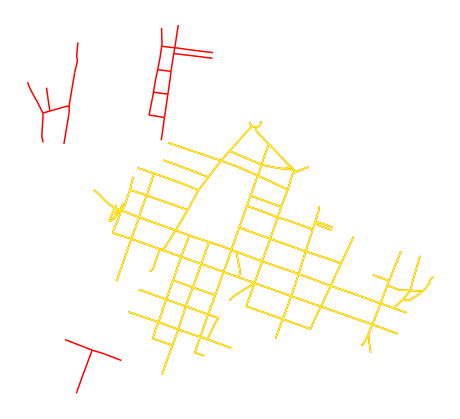

desambrois
longueur 112
in cc 87


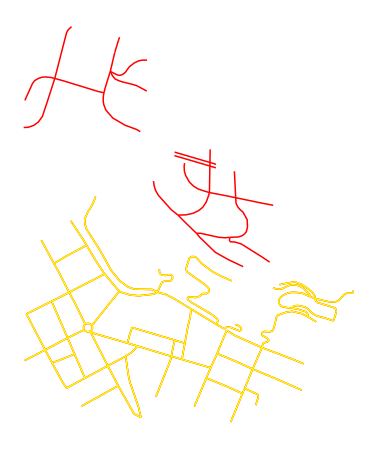

dubouchage
longueur 324
in cc 301


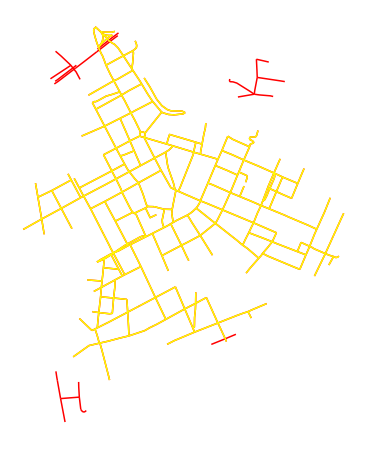

durante
longueur 121
in cc 121


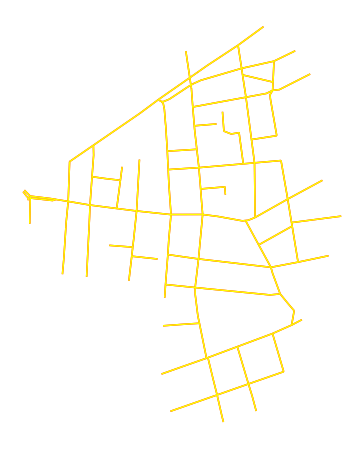

eco vallee
longueur 999
in cc 687


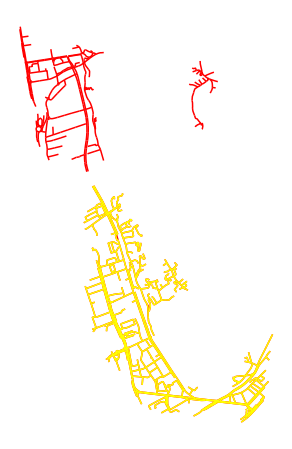

edhec
longueur 901
in cc 788


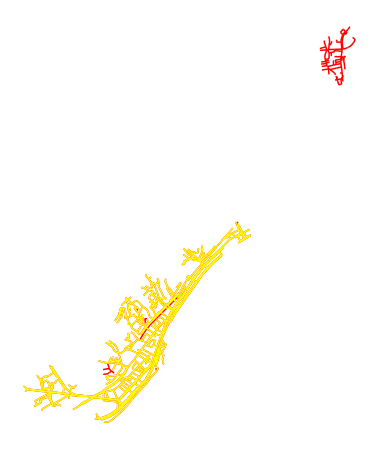

edouard herriot
longueur 41
in cc 41


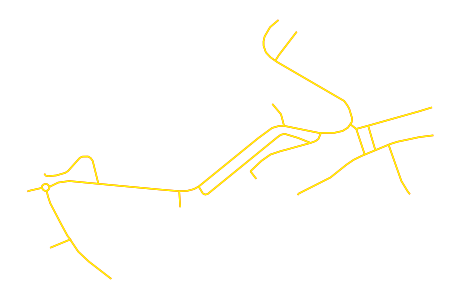

estienne orves
longueur 293
in cc 257


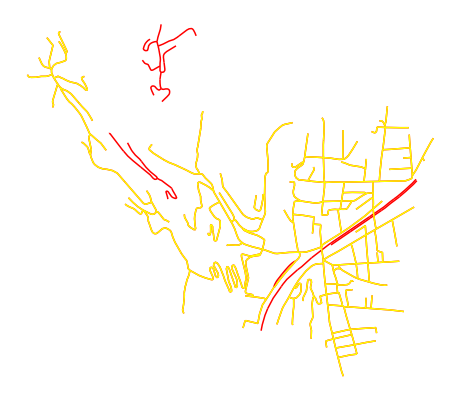

etoile
longueur 429
in cc 406


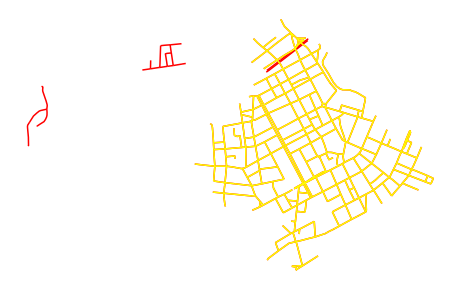

eveche
longueur 344
in cc 293


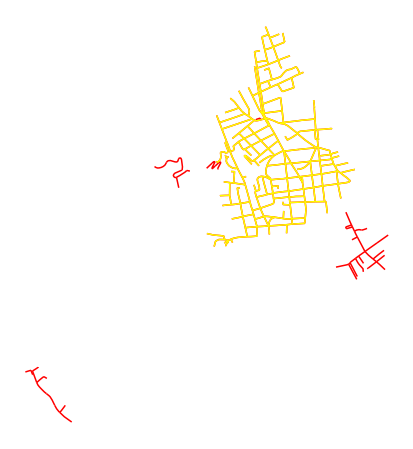

fabron
longueur 1034
in cc 643


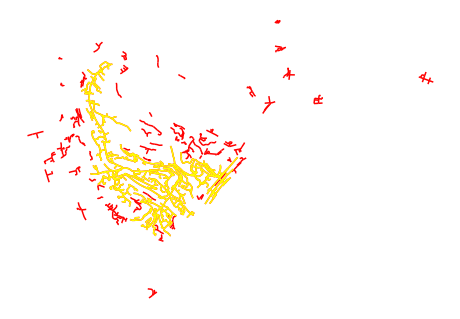

fac lettres
longueur 789
in cc 678


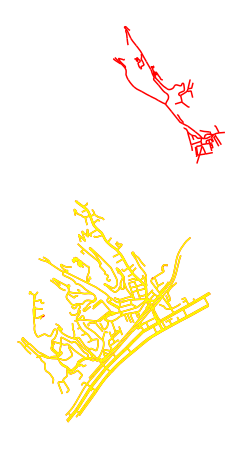

falicon
longueur 732
in cc 562


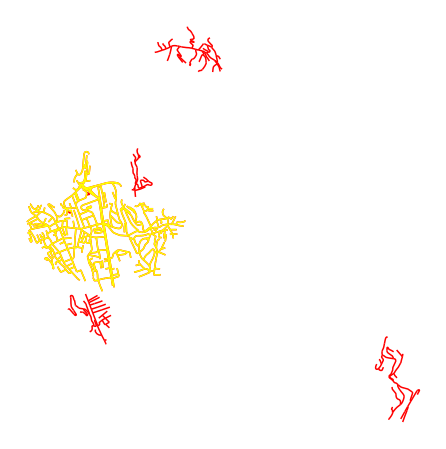

ferber
longueur 837
in cc 490


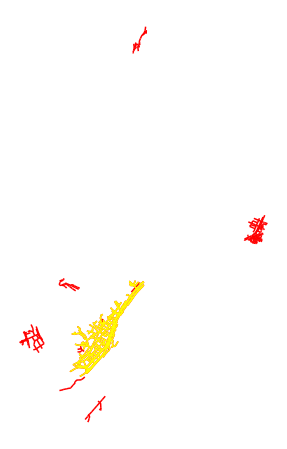

fleurie
longueur 474
in cc 217


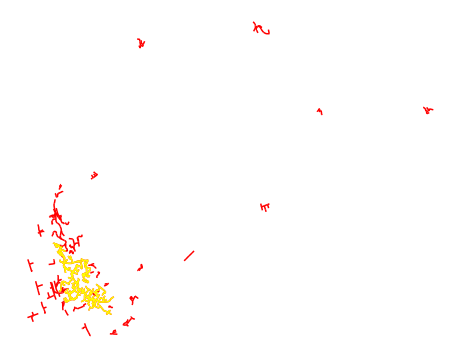

fleurs
longueur 580
in cc 371


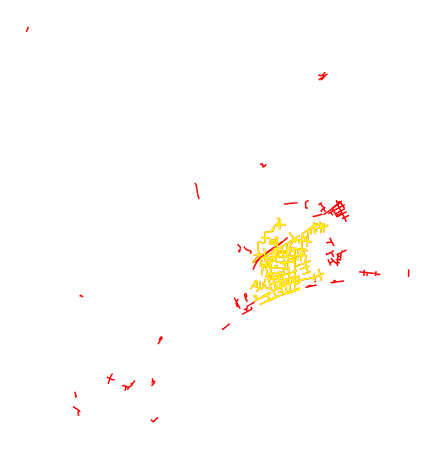

foch
longueur 331
in cc 286


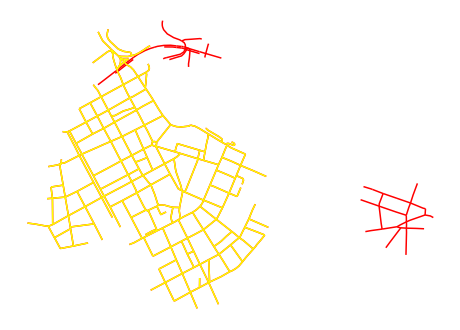

fodere
longueur 83
in cc 73


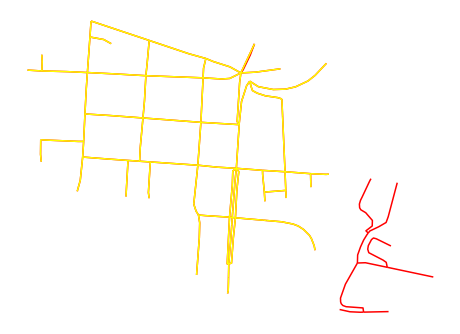

france
longueur 439
in cc 354


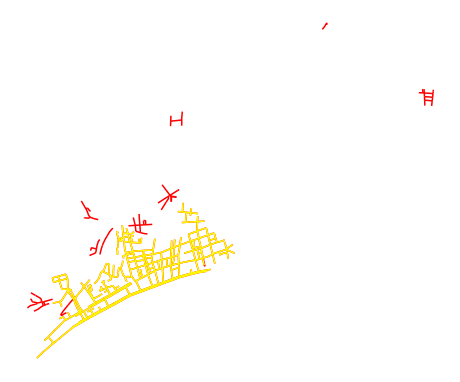

franck pilatte
longueur 124
in cc 92


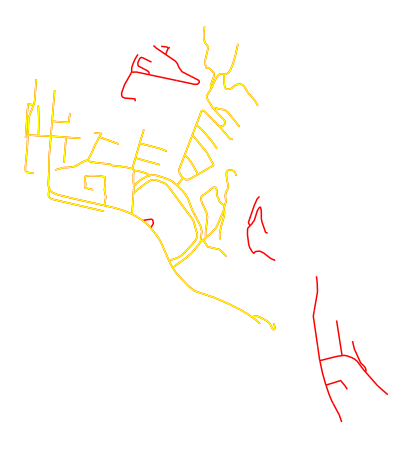

françois
longueur 1534
in cc 1323


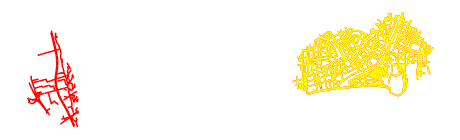

françois grosso
longueur 167
in cc 153


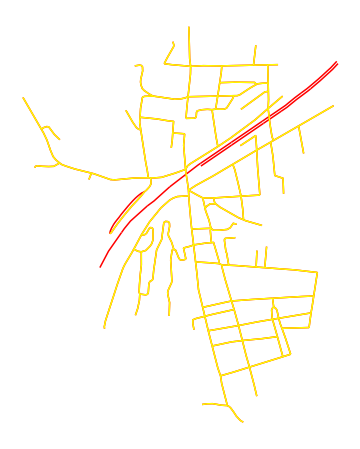

franklin
longueur 410
in cc 299


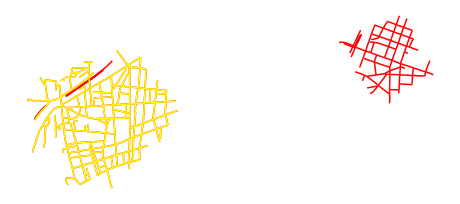

frederic passy
longueur 541
in cc 511


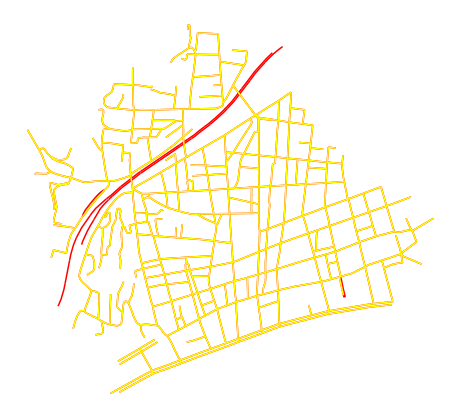

frere marc
longueur 681
in cc 388


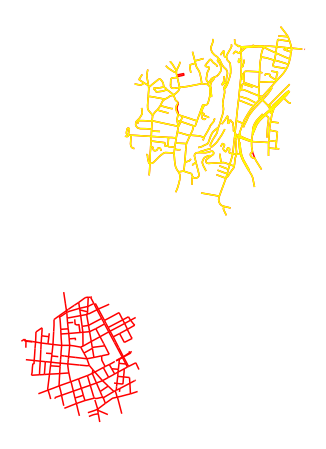

gairaut
longueur 1142
in cc 867


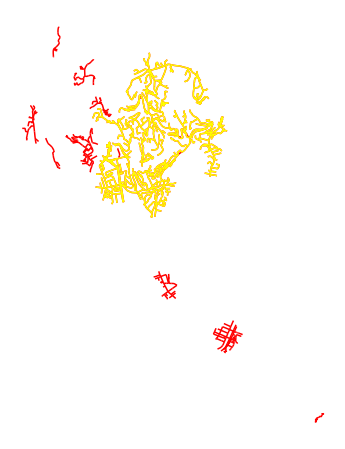

gambetta
longueur 973
in cc 677


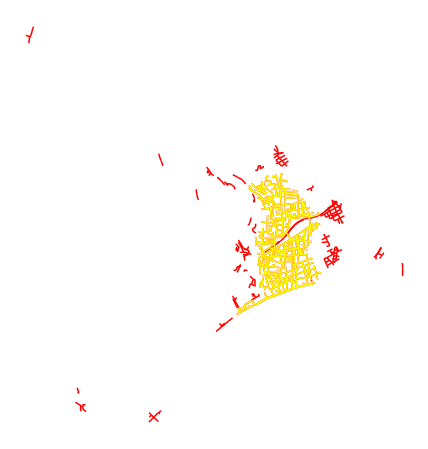

garibaldi
longueur 879
in cc 728


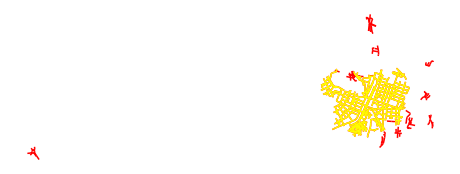

general gaulle
longueur 444
in cc 381


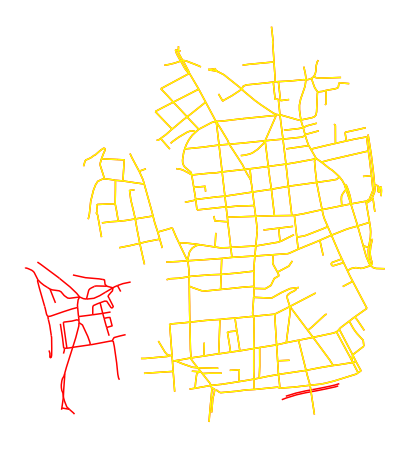

george v
longueur 118
in cc 78


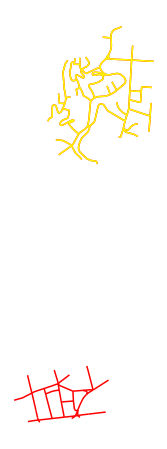

georges clemenceau
longueur 676
in cc 592


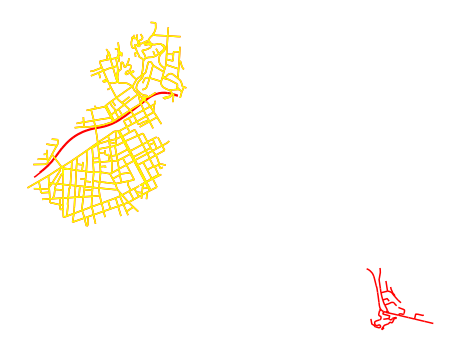

gioffredo
longueur 158
in cc 151


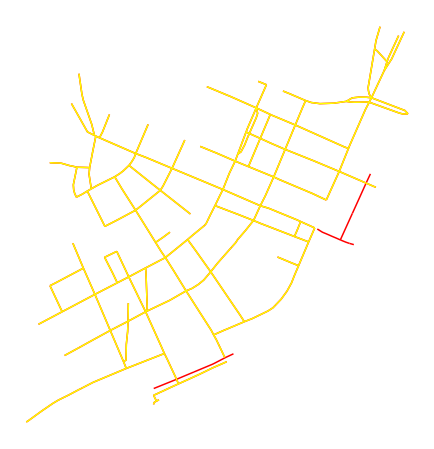

goiran
longueur 749
in cc 462


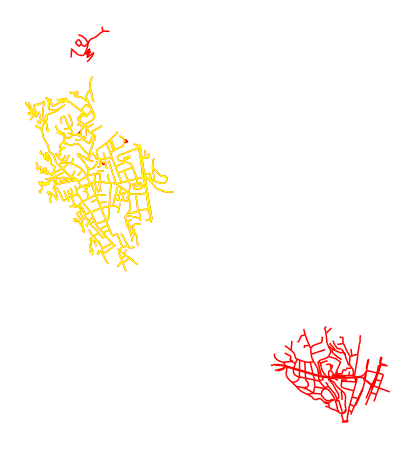

gorbella
longueur 683
in cc 615


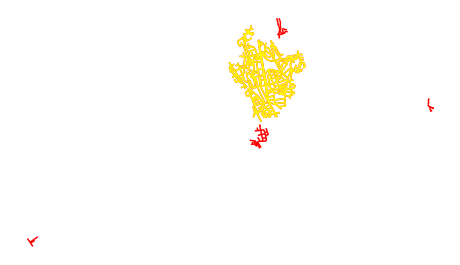

gounod
longueur 595
in cc 526


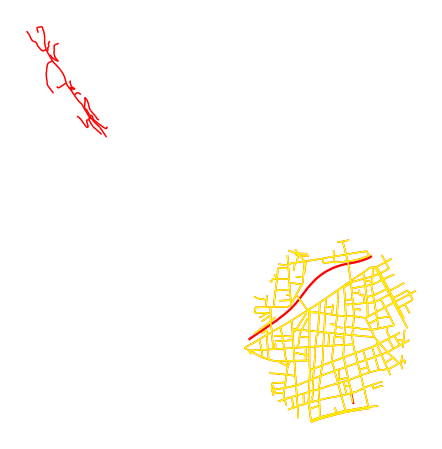

grand arenas
longueur 428
in cc 243


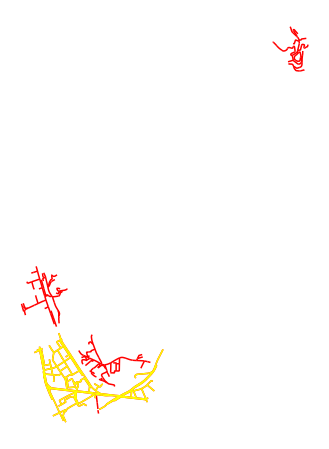

grande corniche
longueur 4019
in cc 3555


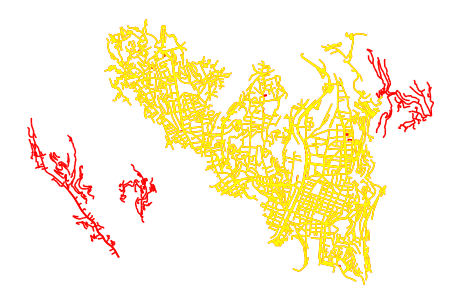

grenoble
longueur 178
in cc 110


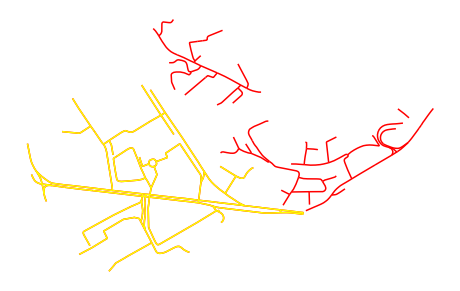

grimaldi
longueur 79
in cc 79


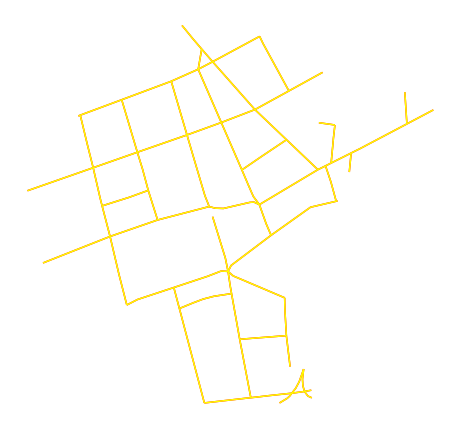

grosso
longueur 354
in cc 316


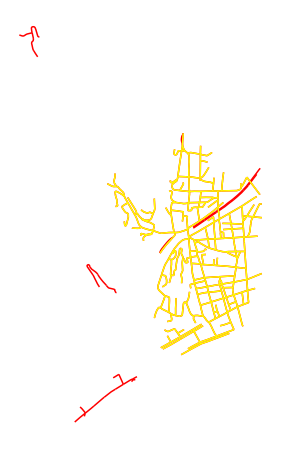

henri matisse
longueur 246
in cc 164


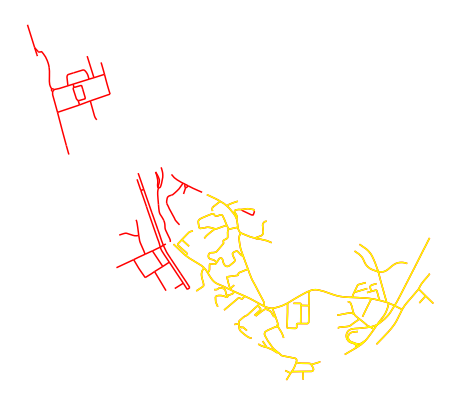

henri sappia
longueur 253
in cc 216


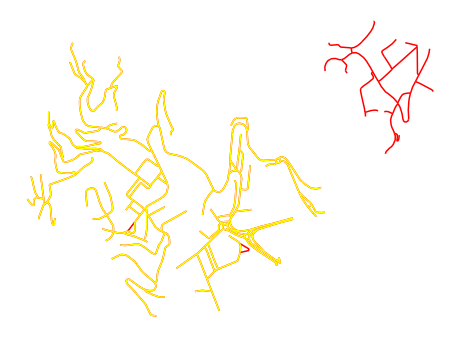

henry dunant
longueur 328
in cc 238


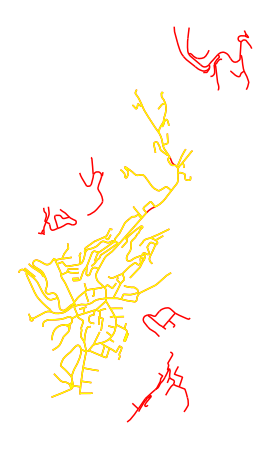

herold
longueur 114
in cc 111


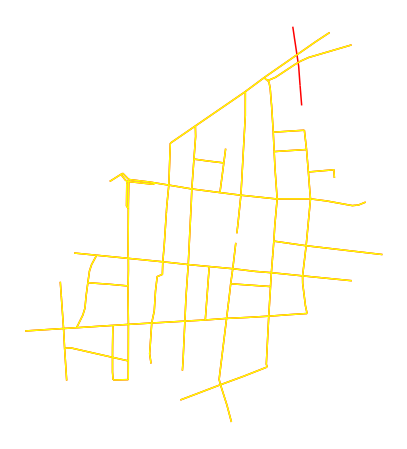

horloge
longueur 541
in cc 515


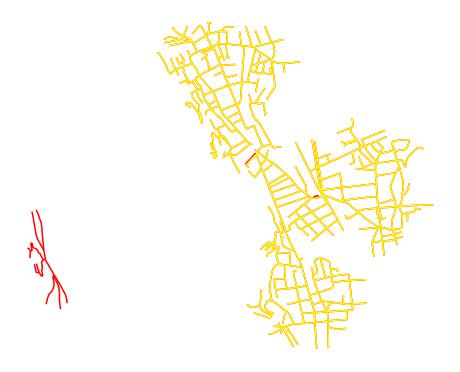

hotel postes
longueur 238
in cc 235


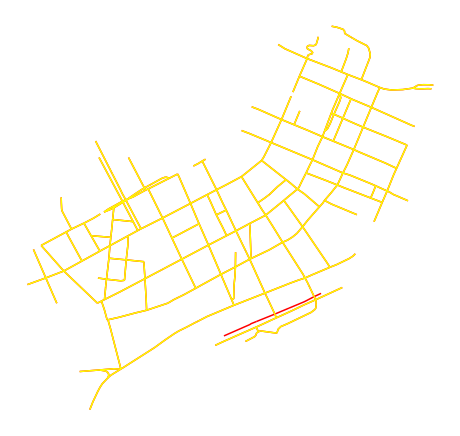

hyper
longueur 857
in cc 825


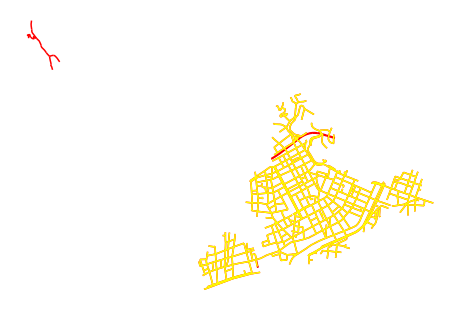

imperial
longueur 456
in cc 433


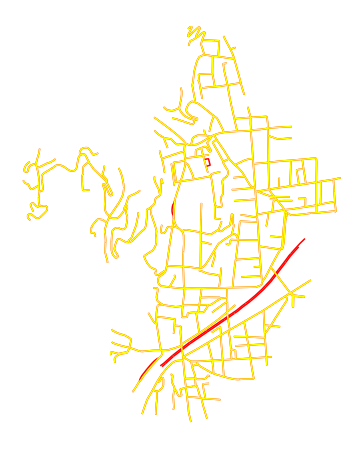

isidore
longueur 1226
in cc 441


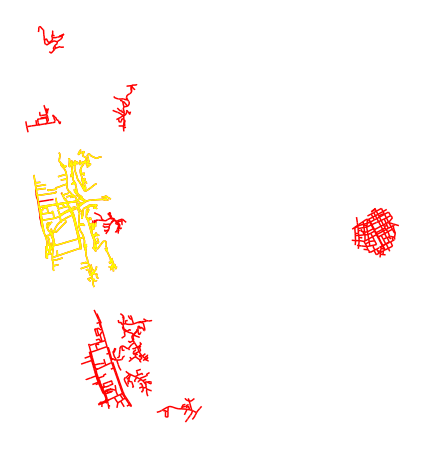

italie
longueur 3237
in cc 2883


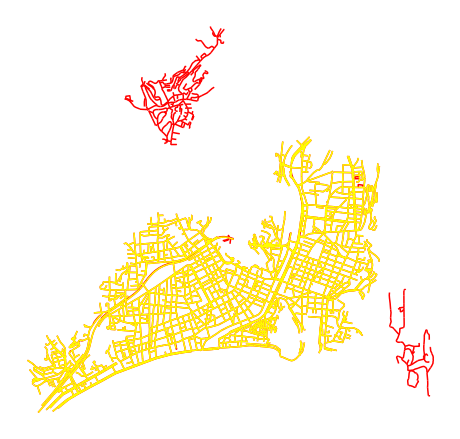

jean angely
longueur 792
in cc 621


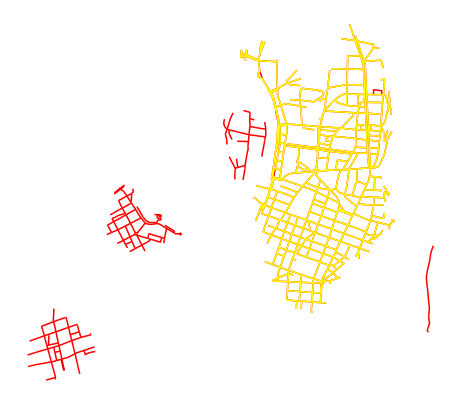

jean behra
longueur 255
in cc 246


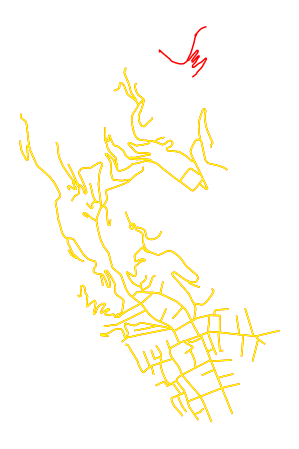

jean cap ferrat
longueur 3818
in cc 3585


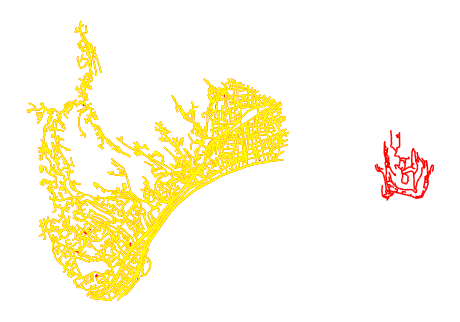

jean medecin
longueur 918
in cc 703


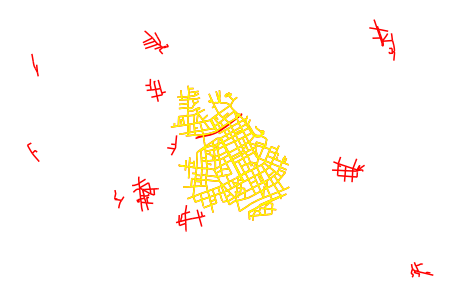

jeannet
longueur 6910
in cc 2971


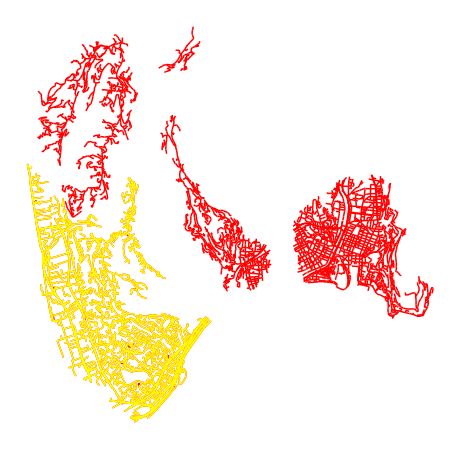

joseph garnier
longueur 224
in cc 213


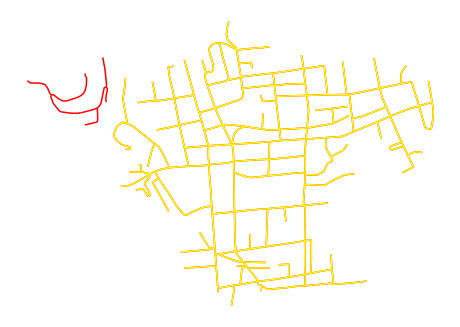

lanterne
longueur 521
in cc 367


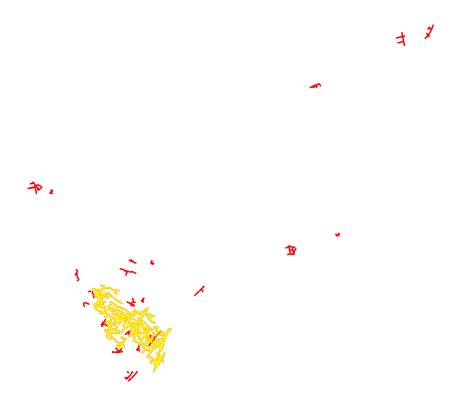

lepante
longueur 207
in cc 176


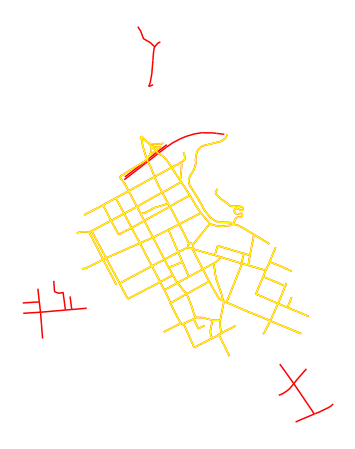

liberation
longueur 879
in cc 661


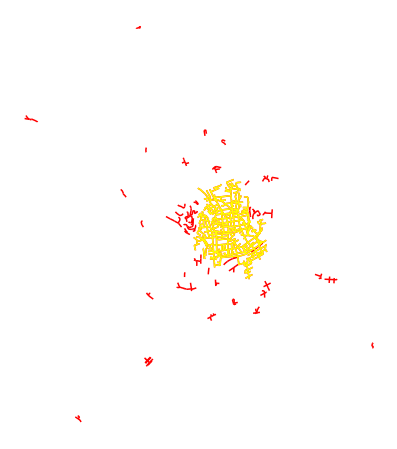

liberte
longueur 356
in cc 307


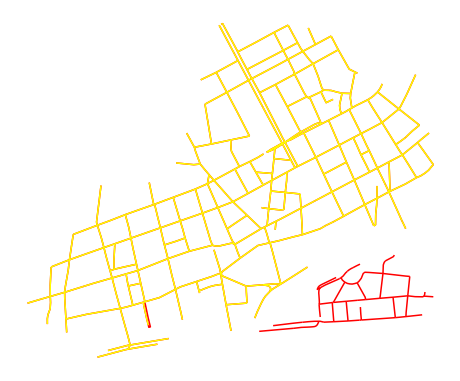

lyautey
longueur 106
in cc 106


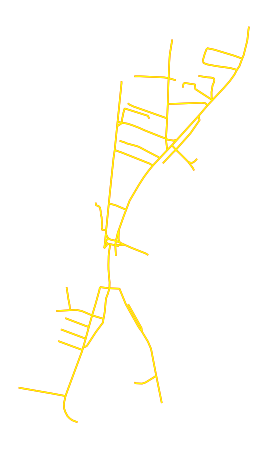

madeleine
longueur 622
in cc 326


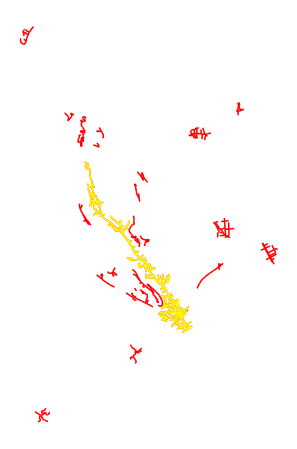

magnan
longueur 767
in cc 372


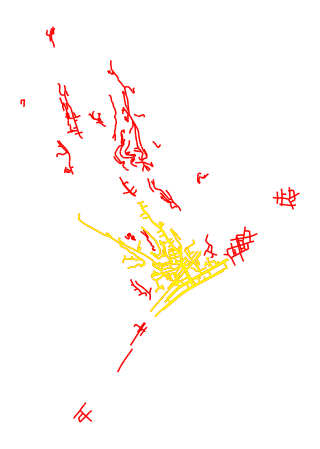

malaussena
longueur 154
in cc 135


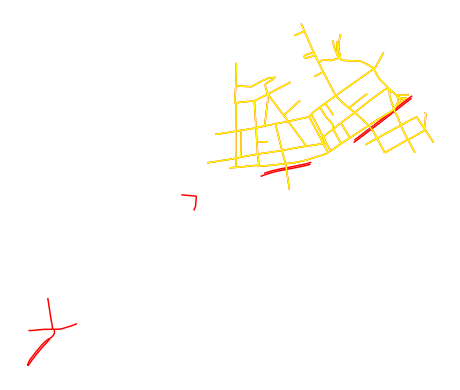

mantega
longueur 553
in cc 501


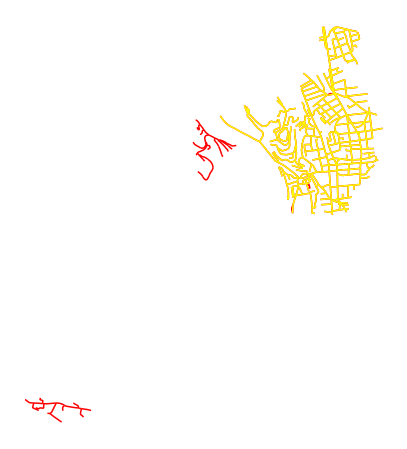

mantega righi
longueur 442
in cc 427


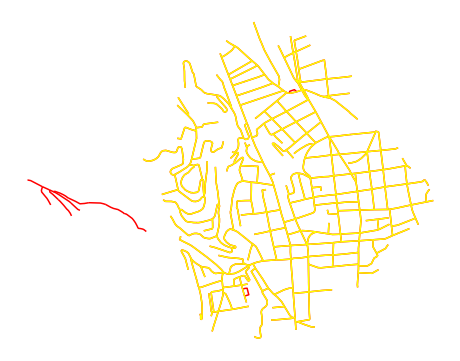

marceau
longueur 80
in cc 64


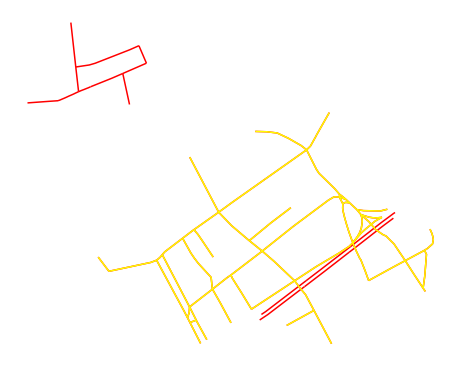

marechal joffre
longueur 366
in cc 327


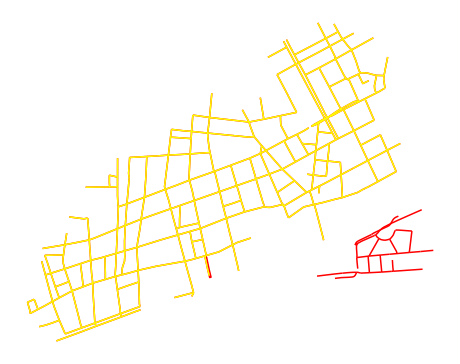

marguerite
longueur 884
in cc 334


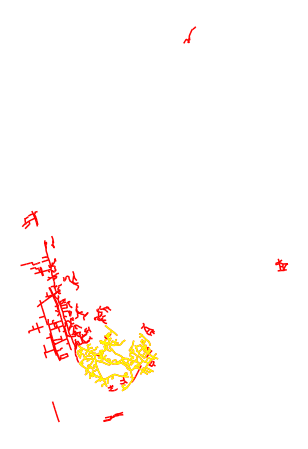

massena
longueur 1052
in cc 868


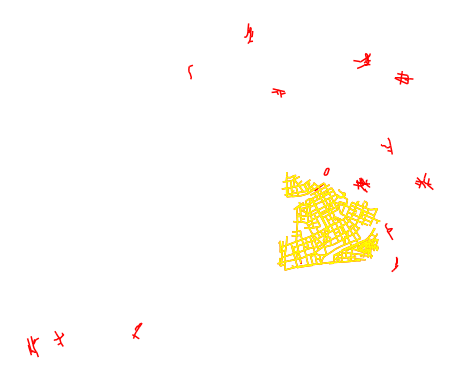

mathis
longueur 5164
in cc 5144


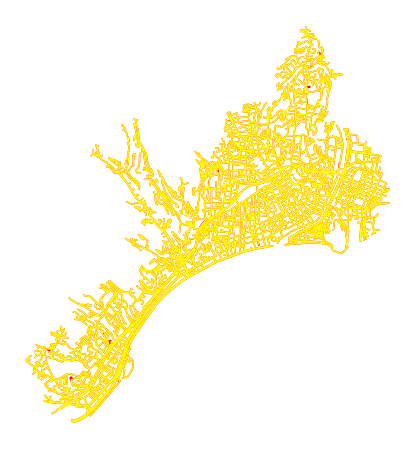

matisse
longueur 2493
in cc 1267


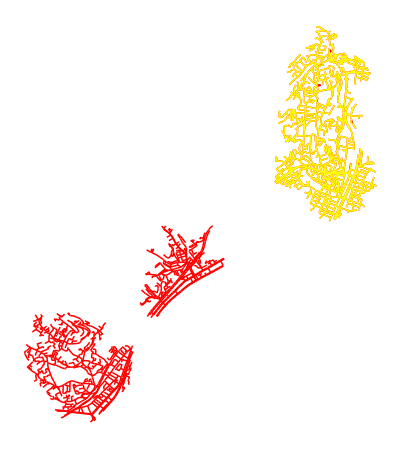

maurice
longueur 584
in cc 563


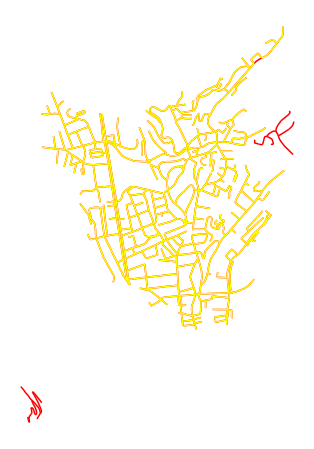

medecin
longueur 609
in cc 581


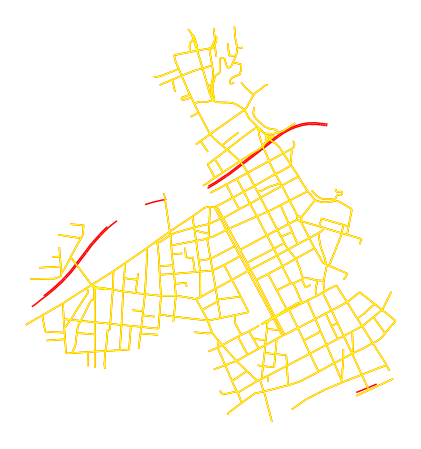

mediterranee
longueur 7488
in cc 7435


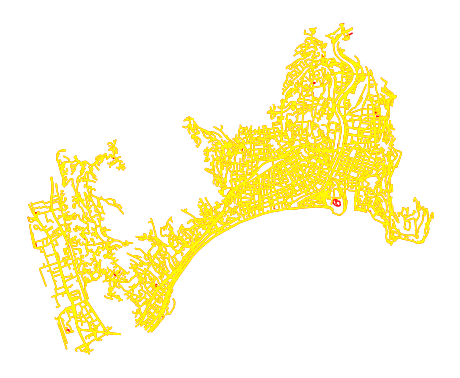

meridia
longueur 781
in cc 545


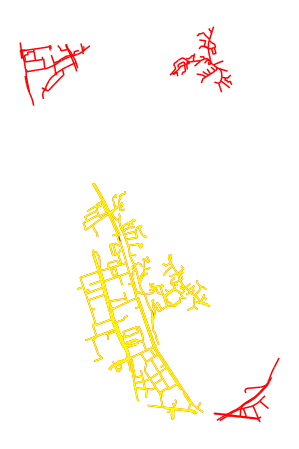

meyerbeer
longueur 397
in cc 367


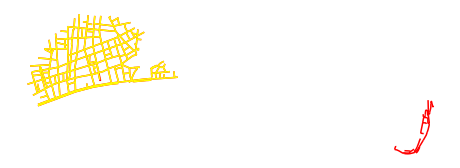

mirabeau
longueur 65
in cc 56


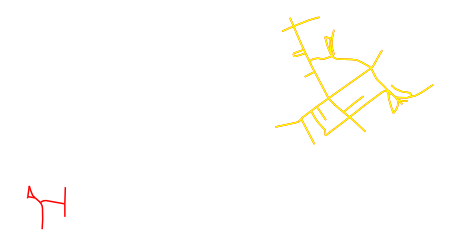

miron
longueur 31
in cc 31


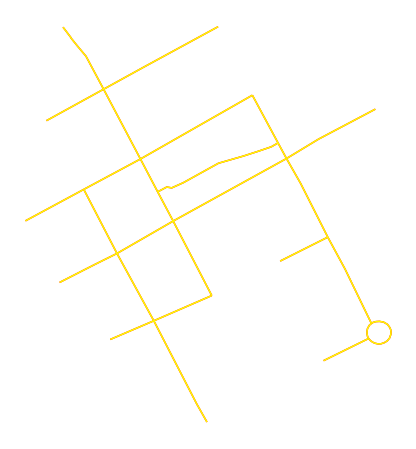

monaco
longueur 5083
in cc 4111


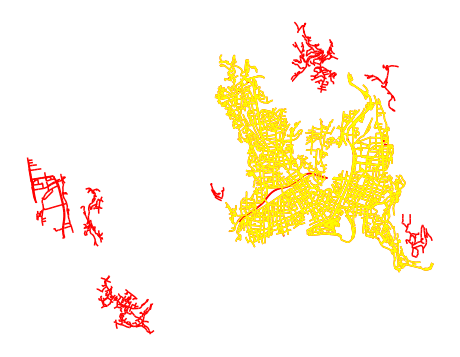

monastere
longueur 360
in cc 193


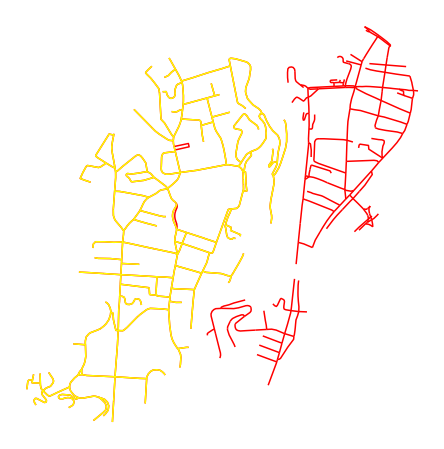

montreal
longueur 120
in cc 69


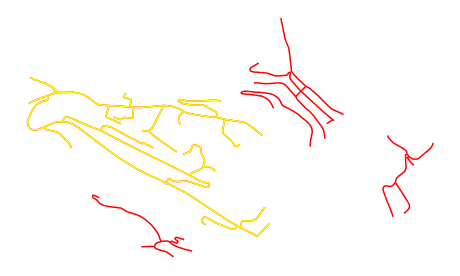

mozart
longueur 168
in cc 140


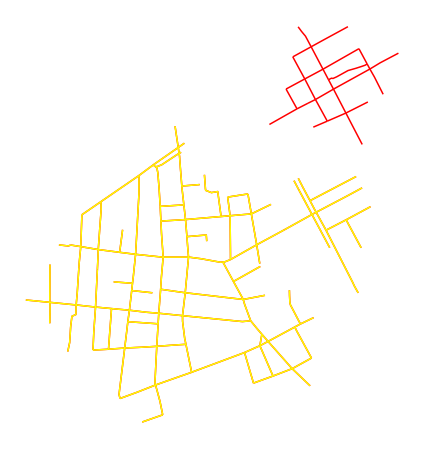

musicien
longueur 544
in cc 458


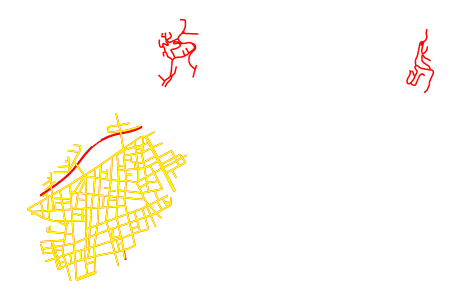

musiciens
longueur 394
in cc 283


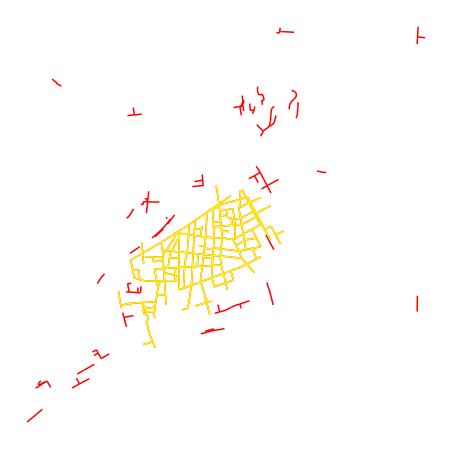

napoleon
longueur 667
in cc 518


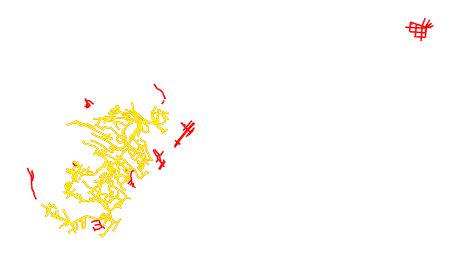

negresco
longueur 365
in cc 251


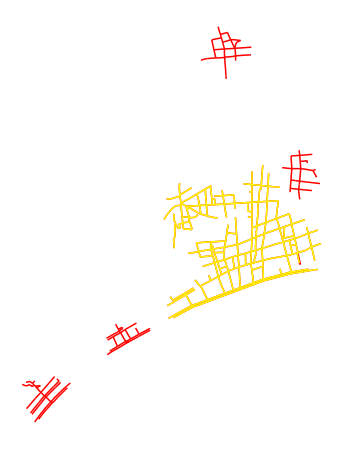

notre dame
longueur 494
in cc 469


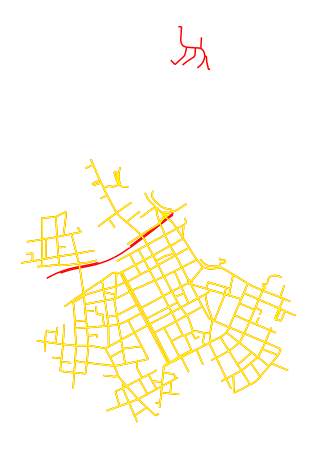

oliviers
longueur 1687
in cc 906


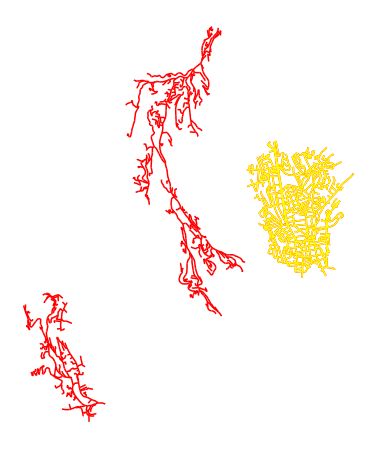

orangers
longueur 55
in cc 44


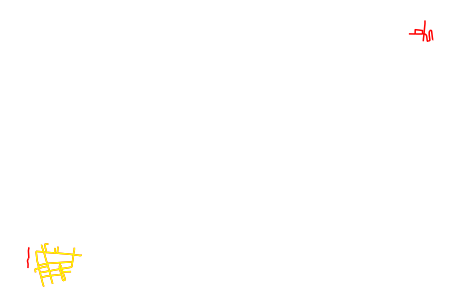

p
longueur 628
in cc 531


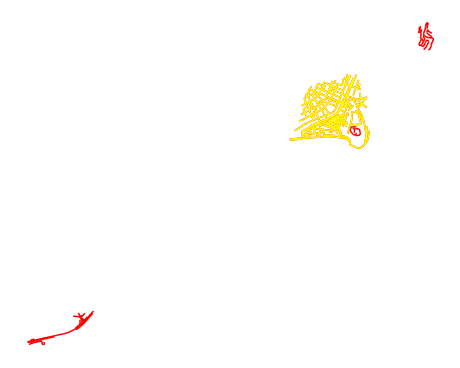

paillon
longueur 2528
in cc 2211


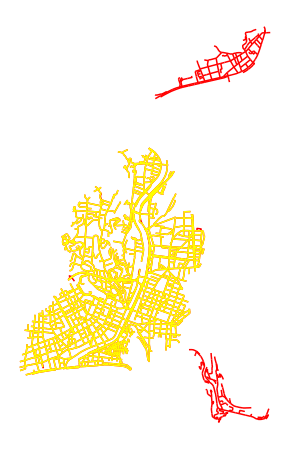

palais expositions
longueur 1025
in cc 616


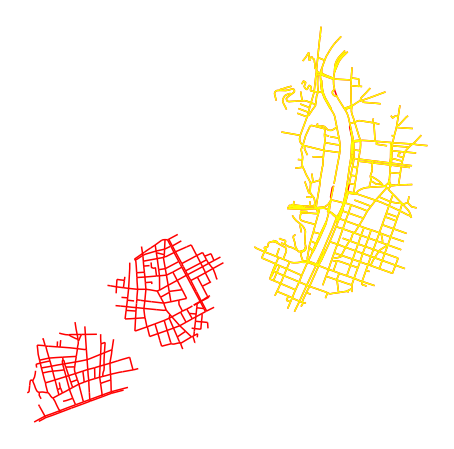

palais festival
longueur 3612
in cc 3271


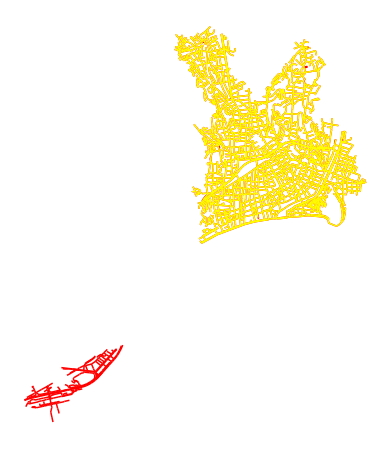

palais justice
longueur 2474
in cc 1865


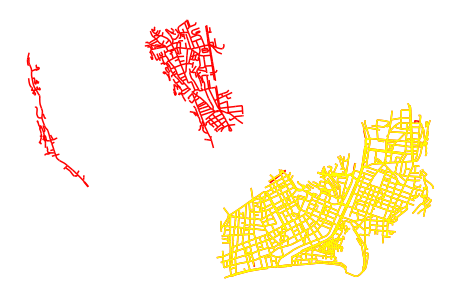

palais mediterranee
longueur 148
in cc 147


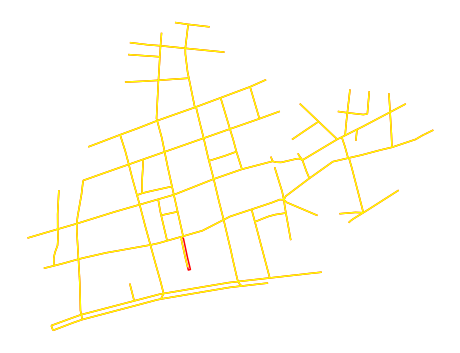

palmiers
longueur 3045
in cc 1795


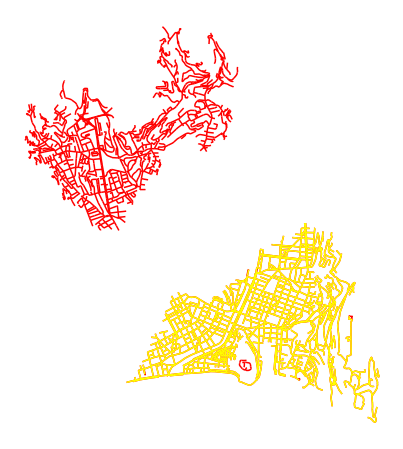

pancrace
longueur 878
in cc 410


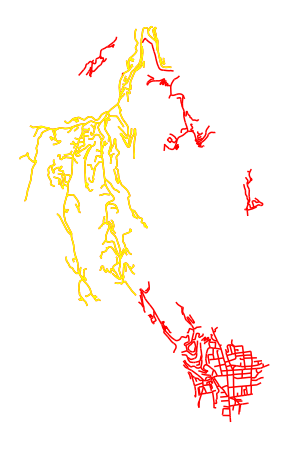

passy
longueur 340
in cc 314


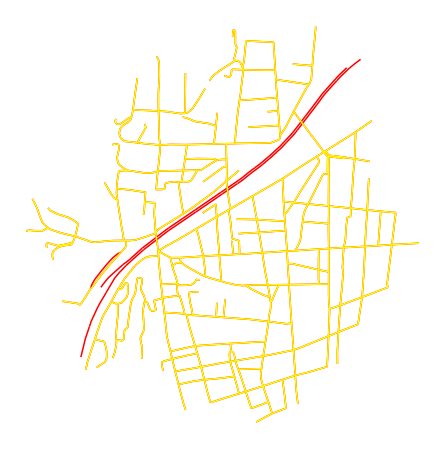

pasteur
longueur 539
in cc 269


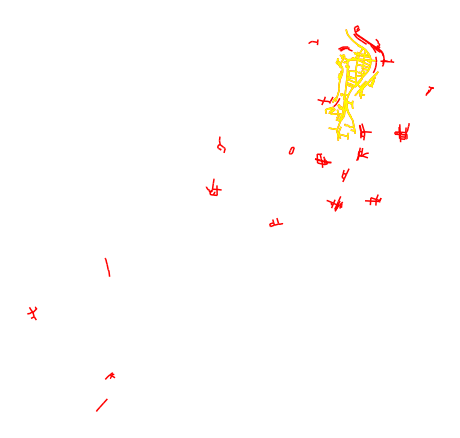

pastorelli
longueur 337
in cc 302


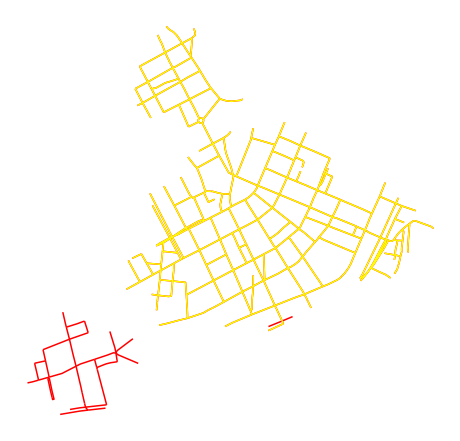

pessicart
longueur 782
in cc 445


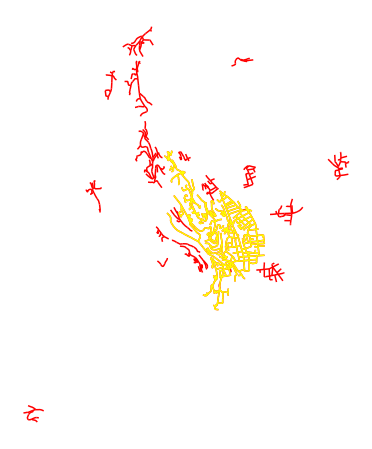

philippe
longueur 795
in cc 545


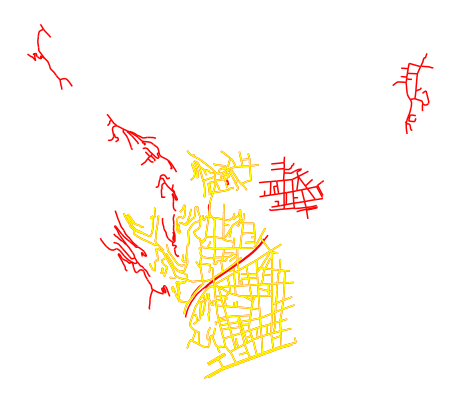

pierre feric
longueur 825
in cc 400


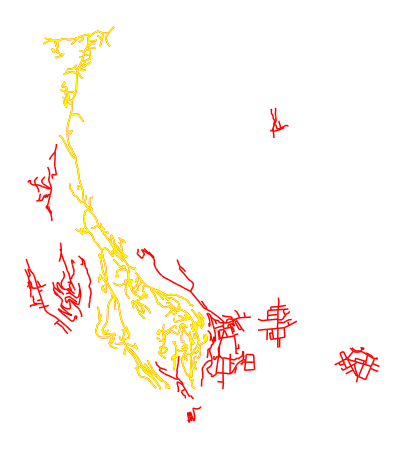

pietonne
longueur 305
in cc 245


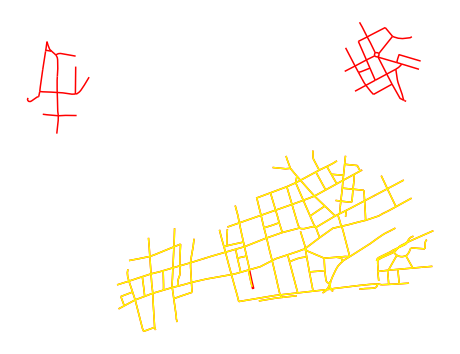

pignata
longueur 376
in cc 236


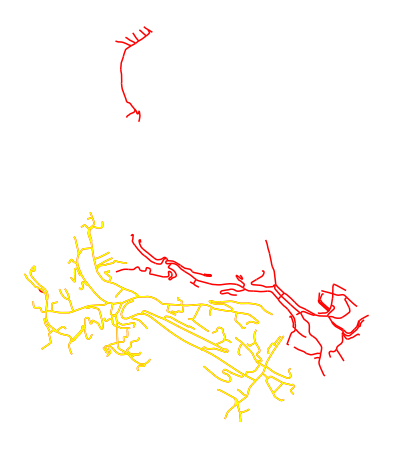

pin
longueur 534
in cc 508


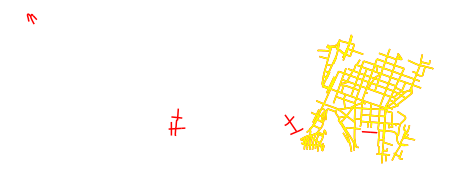

piol
longueur 884
in cc 759


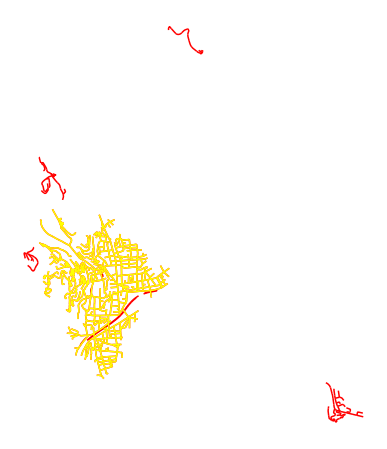

plaine var
longueur 857
in cc 815


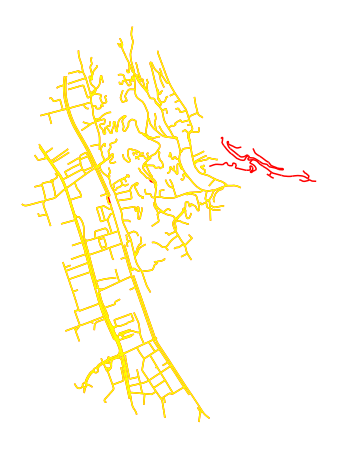

poetes
longueur 405
in cc 342


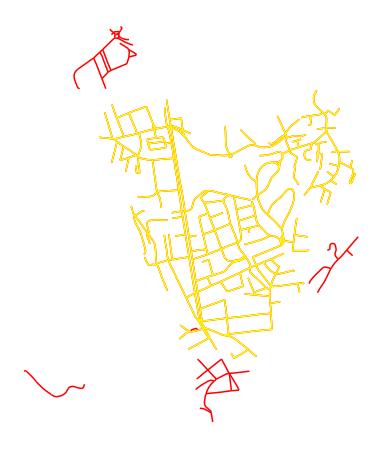

port
longueur 540
in cc 392


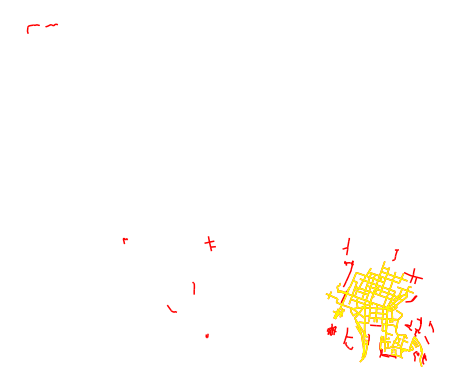

potiers
longueur 111
in cc 111


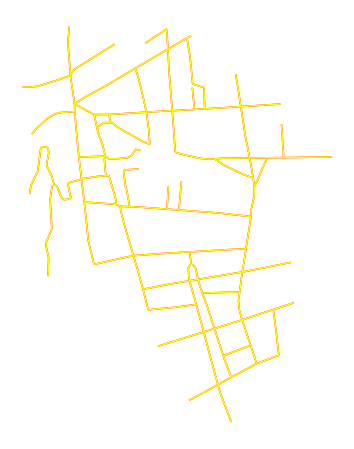

raoul dufy
longueur 1056
in cc 620


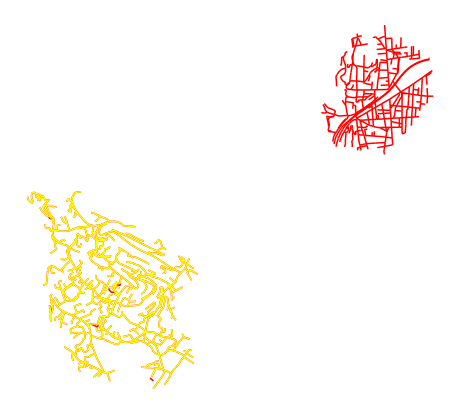

ray
longueur 590
in cc 555


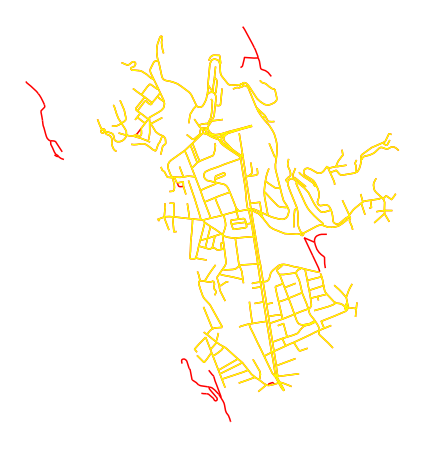

regina
longueur 986
in cc 737


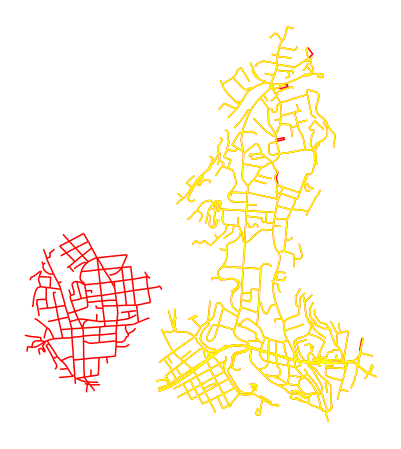

rene cassin
longueur 143
in cc 134


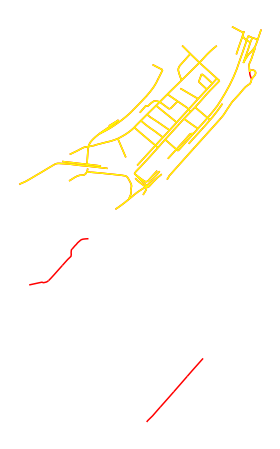

republique
longueur 308
in cc 278


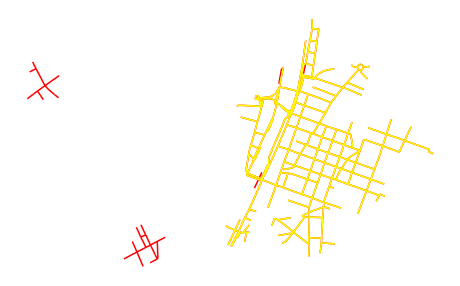

righi
longueur 109
in cc 73


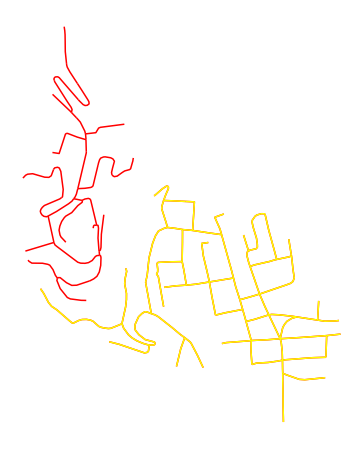

rimiez
longueur 1924
in cc 1294


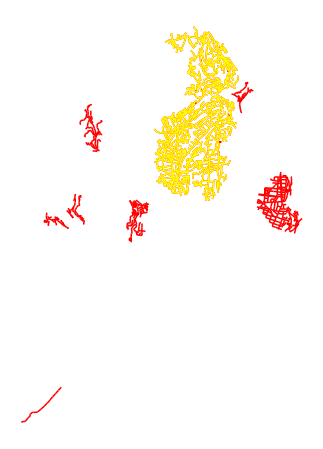

riquier
longueur 697
in cc 530


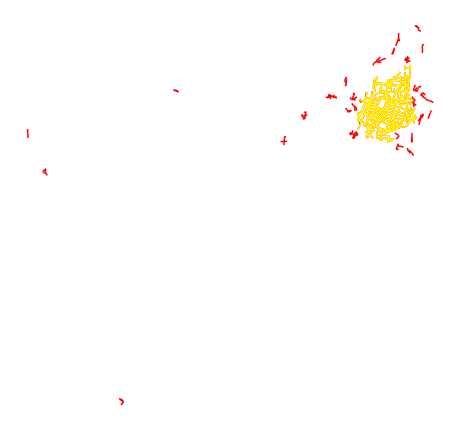

roch
longueur 584
in cc 455


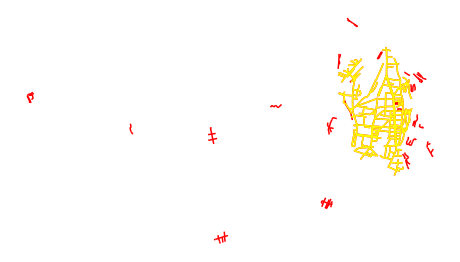

roman bellet
longueur 1174
in cc 486


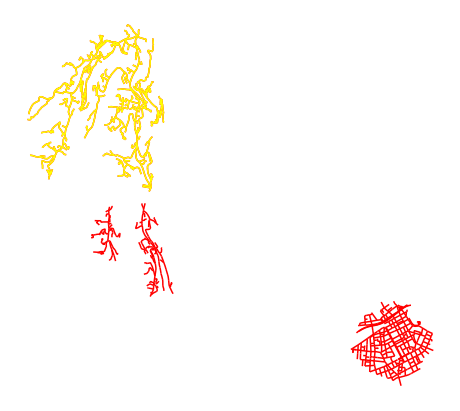

rossetti
longueur 210
in cc 149


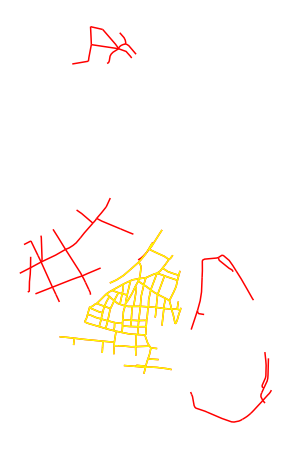

rossini
longueur 190
in cc 153


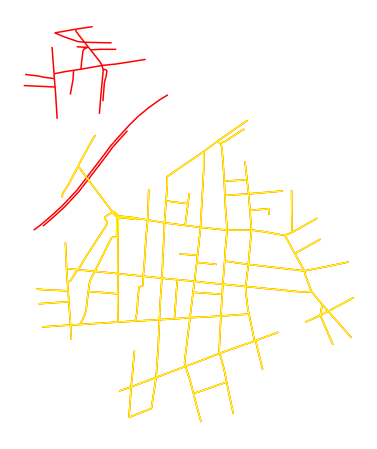

russe
longueur 1609
in cc 1209


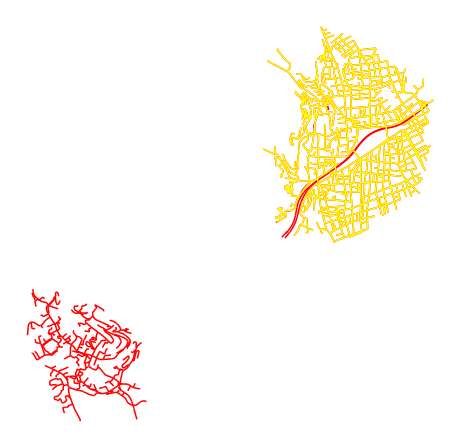

saleya
longueur 633
in cc 425


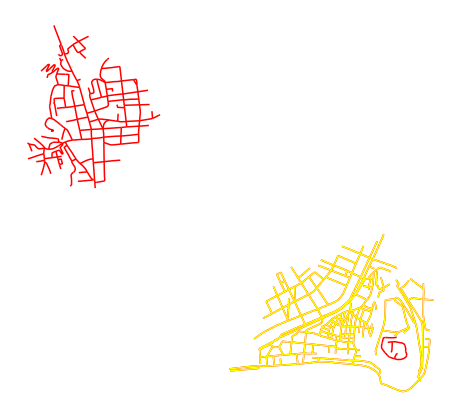

scuderi
longueur 116
in cc 88


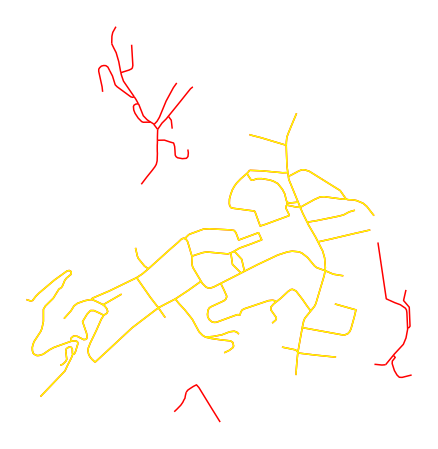

shakespeare
longueur 277
in cc 261


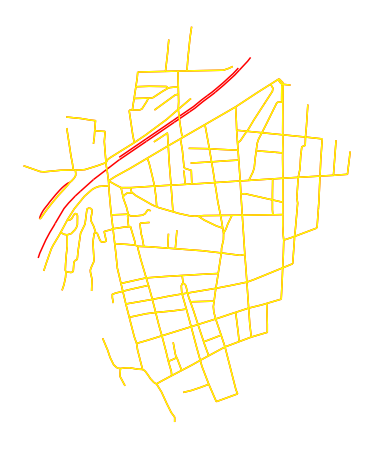

smolett
longueur 114
in cc 81


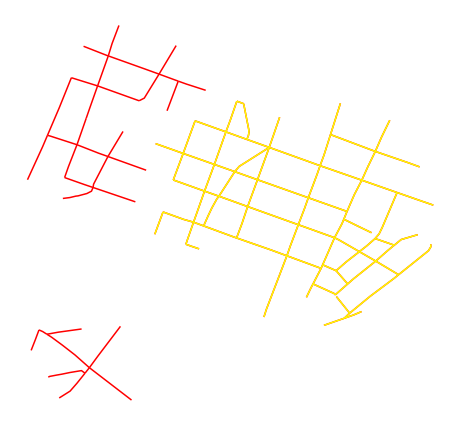

st
longueur 6426
in cc 5048


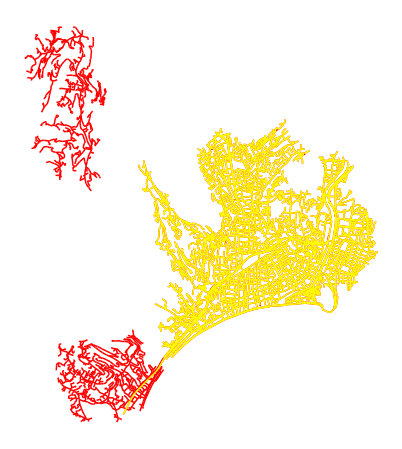

stalingrad
longueur 75
in cc 48


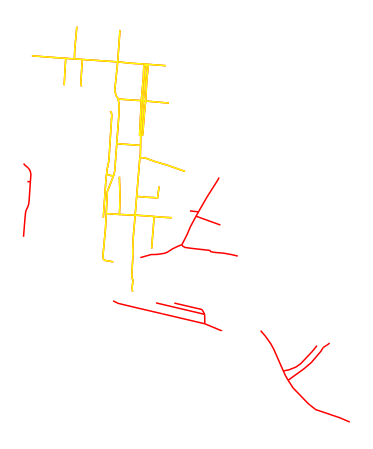

sylvestre
longueur 623
in cc 424


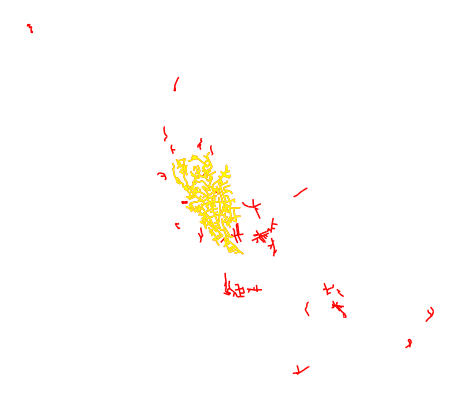

temple
longueur 252
in cc 250


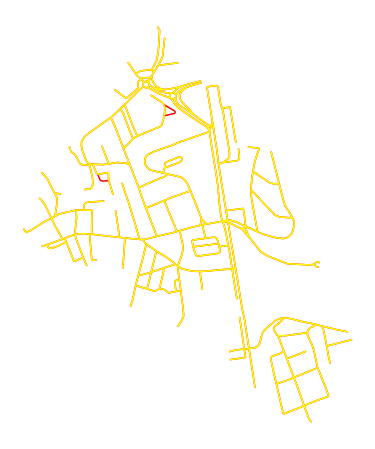

terron
longueur 310
in cc 205


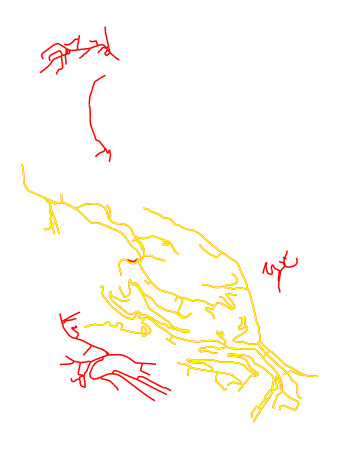

thiers
longueur 964
in cc 878


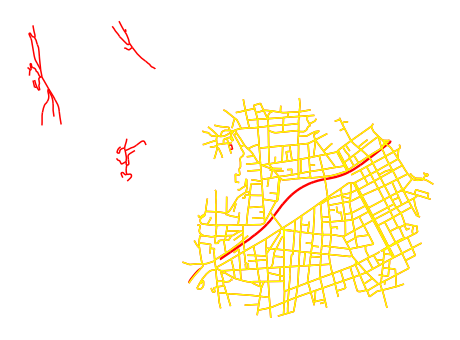

tnl
longueur 301
in cc 293


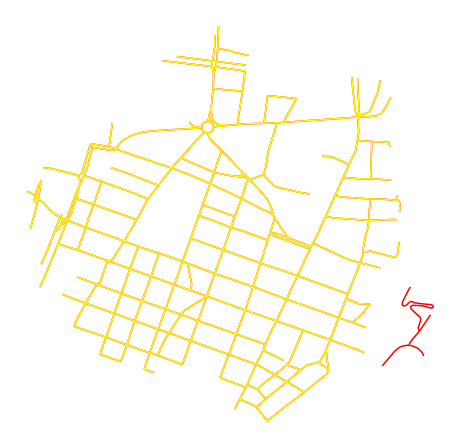

trachel
longueur 99
in cc 72


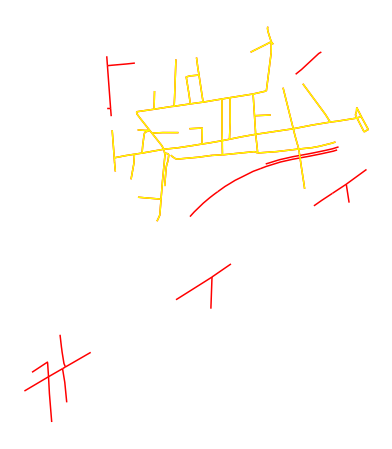

turin
longueur 650
in cc 570


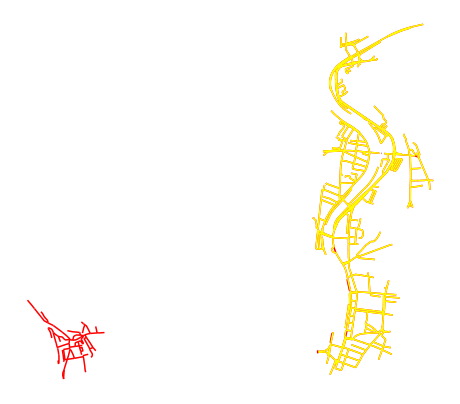

tzarewitch
longueur 80
in cc 73


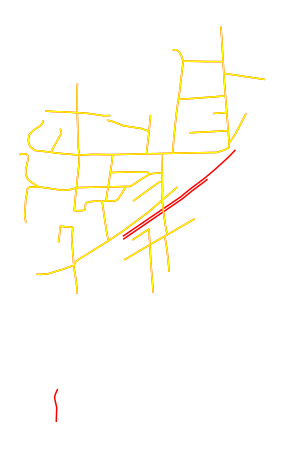

valliere
longueur 669
in cc 365


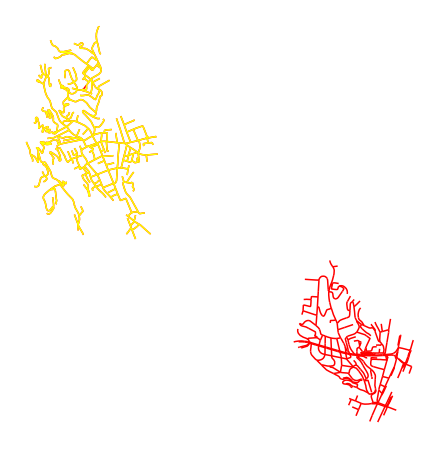

vallon barla
longueur 78
in cc 62


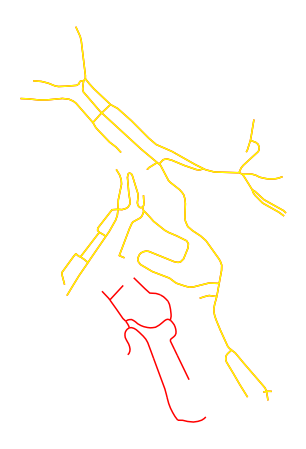

valrose
longueur 716
in cc 596


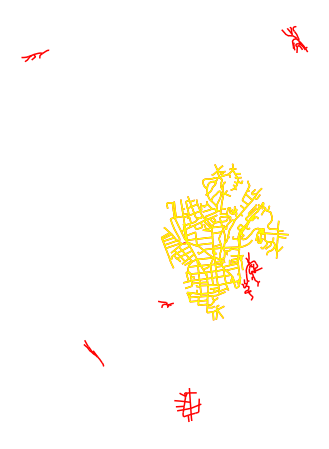

var
longueur 5674
in cc 3216


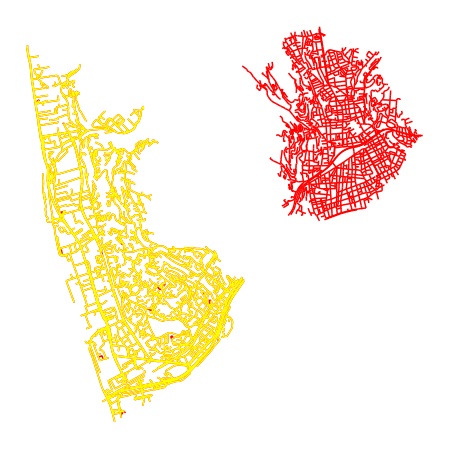

vauban
longueur 268
in cc 231


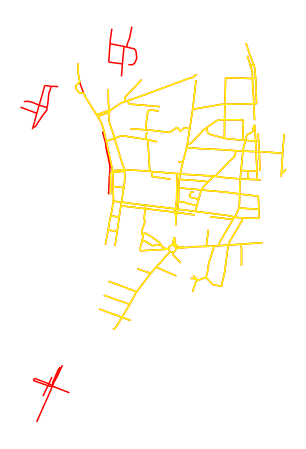

ventabrun
longueur 259
in cc 129


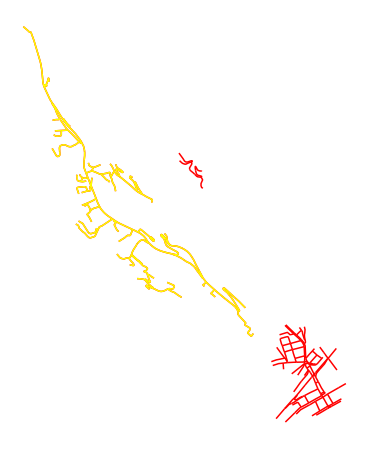

verdi
longueur 91
in cc 91


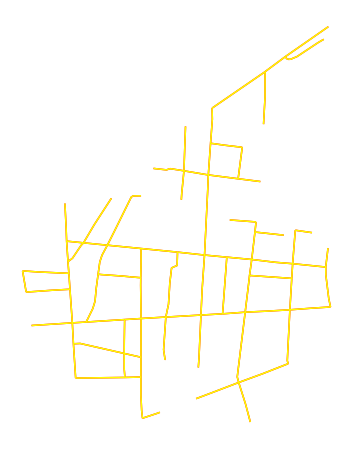

vernier
longueur 208
in cc 169


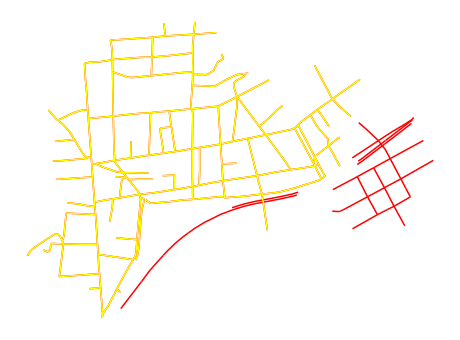

viager
longueur 8386
in cc 8351


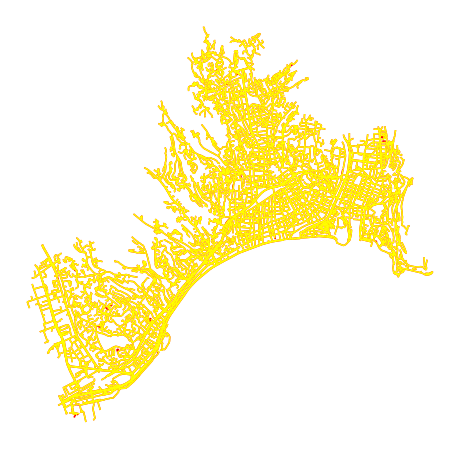

victor hugo
longueur 617
in cc 565


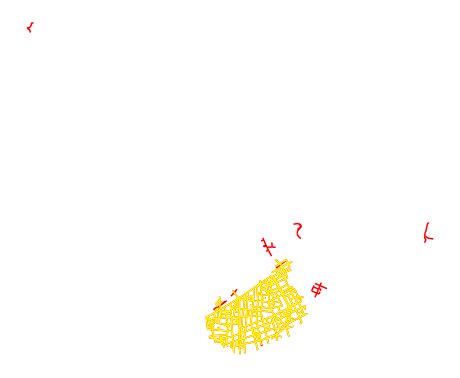

vieille ville
longueur 1262
in cc 1137


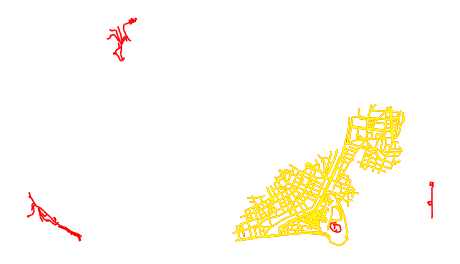

vieux
longueur 1578
in cc 890


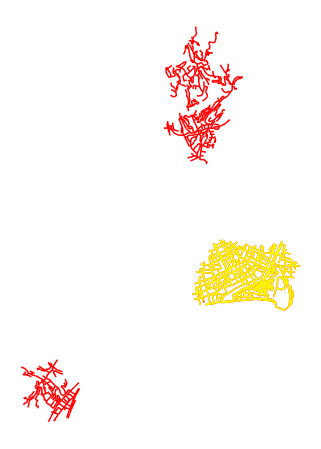

vieux nice
longueur 494
in cc 360


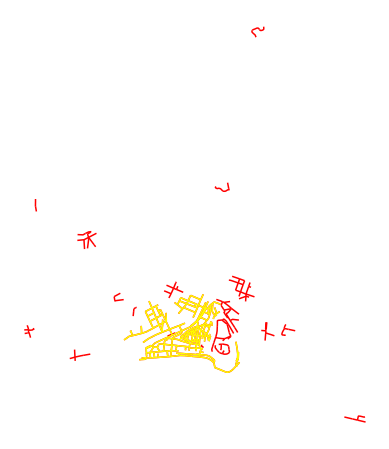

virgile barel
longueur 40
in cc 33


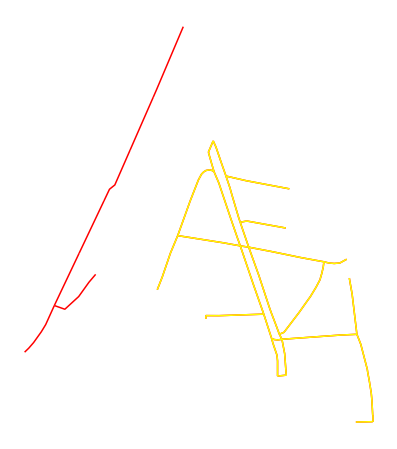

wilson
longueur 244
in cc 185


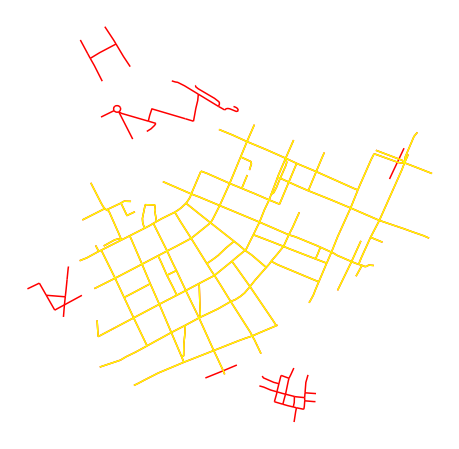

In [12]:
## PHENOME POSITIF 

for col_name in gdf.columns:
    
    # Exclure la colonne 
    if col_name not in notcol:
        print(col_name)
    
        # Extraire les identifiants dont les valeurs sont supérieures à 0
        gdf[col_name] = gdf[col_name].astype(float)
        
        
        ## SELECT INTERVAL ON LIXELS POSITIFS
        list_id_yes = list(set(list(gdf.loc[gdf[col_name] > ((gdf[col_name].max())/100) ].lineID)))
        ## DELATE LIXELS NOT IN INTERVALE 
        gdf[col_name] = gdf.apply(lambda x : x[col_name] if (x['lineID'] in list_id_yes) else 0, axis=1)
        
        
        
        TOPONYM = gdf.loc[gdf[col_name] > 0.0]
        print("longueur", len(TOPONYM))
        
        
        G = momepy.gdf_to_nx(TOPONYM, approach='primal')
        #Extraire première composante connexe
        largest_cc = max(nx.connected_components(G), key=len)
        CC = G.subgraph(largest_cc)
        CC1 = nx.Graph(CC)

        ## Noeuds et liens de la première CC
        subgraph_end_nodes, subgraph_end_edges = momepy.nx_to_gdf(CC1)
        


        # Retrieve the node identifiers of the Subgraph
        subgraph_edges_lineID = list(subgraph_end_edges["lineID"])
        len(subgraph_edges_lineID)
        gdf[col_name] = gdf.apply(lambda x: x[col_name] if x['lineID'] in subgraph_edges_lineID else 0, axis=1)
        print("in cc", len(gdf[gdf[col_name] > 0.0]))
        
        
        ##Plot
        f, ax = plt.subplots(figsize=(8,8))
        TOPONYM.plot(ax=ax, color='red', zorder=1) # INIT == VALEURS > 0.1
        subgraph_end_edges.plot(ax=ax, color='yellow', zorder=1) # INIT == VALEURS > 0.1
        ax.set_axis_off()
        plt.show()



In [13]:
#file = open("MY_ADS_AFTER_00_CLEAN_0_0__working_df_1010.pickle", "rb")
path = "C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/2_PHENOMENE_POSITIF.pickle"
with open(path, 'wb') as f:
    pickle.dump(gdf, f)

path = gdf.to_csv("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/2_PHENOMENE_POSITIF.csv")

    # EXTRAIRE LES ANNONCES DANS LE PHENOMENE QUI NE PARLENT PAS DU PHENOMENE A TRAVERS UNE NOTION DE SITUATION (>> Netkde négatif)

In [14]:
ADS_AM= ADS_AM.to_crs(epsg=2154)

DICT = {}
for col_name in gdf.columns:
    
    # Exclure la colonne 
    if col_name not in notcol:
        print(col_name)
        
        TOPONYM = gdf.loc[gdf[col_name] > 0.0] #.unary_union
        # Fusion des lignes de la même composante connexe
        G = momepy.gdf_to_nx(TOPONYM, approach='primal')
        TOPONYM_edges = [G.edges[edge]['geometry'] for edge in G.edges]
        TOPONYM_edges_merged_lines = linemerge(TOPONYM_edges)
        TOPONYM_BUFFER = TOPONYM_edges_merged_lines.buffer(2) 
        #type(TOPONYM_BUFFER)
        #print('buff')
        t = gpd.GeoDataFrame(index=[0], crs='epsg:2154', geometry=[TOPONYM_BUFFER])
        test = ADS_AM.loc[ADS_AM.within(t.loc[0,'geometry'])]
        #print("longueur intersect",len(test))

            ## V1 CHOOSE NNONLY WHERE TOPO_3 == TOPONYME
        ADS_WANT =  test.loc[test['cat_rs'] == "IN"] #Choose knowledges = IN
        #len(ADS_WANT)
        ADS_WANT_YES =  ADS_WANT.loc[ADS_WANT['topo_3'] == col_name]
        #print(len(ADS_WANT_YES))
        list_index_yes = list(set(list(ADS_WANT_YES['idAnnonce'])))
        #print(len(list_index_yes))
        ADS_WANT_NO = ADS_WANT.loc[ADS_WANT['topo_3'] != col_name] 
        #len(ADS_WANT_NO)
        ADS_WANT_NO = ADS_WANT_NO[~ADS_WANT_NO['idAnnonce'].isin(list_index_yes)]
        #len(ADS_WANT_NO)
        list_index_no = list(set(list(ADS_WANT_NO['idAnnonce'])))
        print(len(list_index_no))
        
        
           ## V2 CHOOSE NNONlY WITH REGEX
        #ADS_WANT =  test.loc[test['cat_rs'] == "IN"] #Choose knowledges = IN
        #ADS_WANT = ADS_WANT.drop_duplicates(subset=['idAnnonce'])
        #ADS_WANT = ADS_WANT[~ADS_WANT.DESCRIPTION.str.contains(col_name, regex= True, na=False)]
        #list_index_no = list(set(list(ADS_WANT['idAnnonce'])))


        DICT[col_name] = list_index_no
        print("ok", len(DICT))

acropolis
buff
longueur intersect 9772
107
104
2203
ok 1
alban
buff
longueur intersect 15818
44
43
3571
ok 2
alphonse karr
buff
longueur intersect 4515
36
33
1186
ok 3
alsace lorraine
buff
longueur intersect 13157
126
104
3106
ok 4
andrioli
buff
longueur intersect 5335
21
19
1117
ok 5
anglais
buff
longueur intersect 29305
859
792
5876
ok 6
antiquaires
buff
longueur intersect 3500
28
28
765
ok 7
antoine
buff
longueur intersect 1880
28
28
378
ok 8
antoine ginestiere
buff
longueur intersect 858
65
62
127
ok 9
archet
buff
longueur intersect 4839
66
63
927
ok 10
arenas
buff
longueur intersect 2943
77
73
424
ok 11
arenes
buff
longueur intersect 3519
59
56
790
ok 12
ariane
buff
longueur intersect 233
65
63
25
ok 13
arson
buff
longueur intersect 4086
56
55
1009
ok 14
auguste raynaud
buff
longueur intersect 2992
16
16
724
ok 15
augustin
buff
longueur intersect 5718
119
112
876
ok 16
baie anges
buff
longueur intersect 31878
19
19
6779
ok 17
barberis
buff
longueur intersect 929
21
17
234
ok 18
ba

longueur intersect 6759
66
63
1506
ok 148
notre dame
buff
longueur intersect 7428
77
72
1843
ok 149
oliviers
buff
longueur intersect 9606
1
1
2362
ok 150
orangers
buff
longueur intersect 1667
18
17
335
ok 151
p
buff
longueur intersect 6391
32
32
1445
ok 152
paillon
buff
longueur intersect 27875
12
12
6778
ok 153
palais expositions
buff
longueur intersect 6429
21
21
1487
ok 154
palais festival
buff
longueur intersect 45518
20
20
11055
ok 155
palais justice
buff
longueur intersect 27129
17
17
6527
ok 156
palais mediterranee
buff
longueur intersect 3489
16
16
884
ok 157
palmiers
buff
longueur intersect 22652
6
6
5325
ok 158
pancrace
buff
longueur intersect 551
43
39
93
ok 159
passy
buff
longueur intersect 7147
13
13
1649
ok 160
pasteur
buff
longueur intersect 2084
285
253
256
ok 161
pastorelli
buff
longueur intersect 4241
25
22
1014
ok 162
pessicart
buff
longueur intersect 4865
182
177
1038
ok 163
philippe
buff
longueur intersect 10480
72
69
2315
ok 164
pierre feric
buff
longueur intersec

In [16]:
with open("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/dict_ads_negatives.json", 'w') as fp:
    json.dump(DICT, fp)

    # save as DF 
 Dataframe général des annonces avec une nouvelle colonne comprenant les toponymes concernés

    # Pour modifications ou problèmes : 

In [1]:
#### POUR 1 100 EME 